# Sistem Peringatan Dini Kegagalan Mesin Industri Berdasarkan Parameter Operasional Menggunakan ANFIS dan Genetic Algorithm

Notebook ini membangun pipeline sistem peringatan dini kegagalan mesin industri menggunakan dataset AI4I 2020 Predictive Maintenance Dataset. Tahapan yang dilakukan meliputi load dataset, data understanding, exploratory data analysis, data cleaning, feature engineering, normalisasi, pemodelan ANFIS tanpa optimasi, pemodelan ANFIS dengan optimasi Genetic Algorithm, visualisasi fungsi keanggotaan fuzzy sebelum dan sesudah optimasi, evaluasi model, interpretasi risk score, serta penyimpanan parameter model.

Dataset yang digunakan bersumber dari Kaggle:

https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020

Target prediksi pada penelitian ini adalah kolom `Machine failure`, dengan nilai 0 untuk kondisi normal dan 1 untuk kondisi gagal. Model menghasilkan risk score dalam rentang 0 sampai 1, kemudian risk score tersebut dikonversi menjadi kelas biner dan status peringatan dini.

## Anggota Kelompok:

* Lukas Austin - 140810230011
* Orlando Bloem Sutono - 140810230057
* Rynad Arkansyah Gunawan - 140810230079

## 1. Import Library

Tahap ini digunakan untuk mengimpor seluruh library yang dibutuhkan pada notebook. Seluruh import diletakkan pada awal notebook agar struktur kode lebih rapi dan tidak ada import tambahan pada bagian bawah. Library yang digunakan mencakup manipulasi data, visualisasi, preprocessing, evaluasi model, dan penyimpanan parameter.

In [ ]:
# Mengimpor library dasar untuk manipulasi file dan konfigurasi
import os
import math
import random
import warnings
import joblib

# Mengimpor library manipulasi data dan komputasi numerik
import numpy as np
import pandas as pd

# Mengimpor library visualisasi
import matplotlib.pyplot as plt

# Mengimpor fungsi display agar tabel pandas dapat ditampilkan lebih rapi di notebook
from IPython.display import display

# Mengimpor library preprocessing, pembagian data, dan evaluasi model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve

# Mengimpor SMOTE untuk menangani ketidakseimbangan kelas pada data latih
from imblearn.over_sampling import SMOTE

# Mengatur peringatan agar output notebook tidak terlalu penuh
warnings.filterwarnings("ignore")

# Mengatur seed agar hasil eksperimen lebih konsisten ketika notebook dijalankan ulang
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## 2. Load Dataset

Tahap ini membaca dataset AI4I 2020 dari file CSV yang telah diunggah secara manual ke Google Colab. Pastikan file `ai4i2020.csv` sudah tersedia pada direktori kerja Colab sebelum menjalankan cell ini.

In [ ]:
# Menentukan nama file dataset yang akan dibaca
csv_filename = "ai4i2020.csv"

# Mengecek apakah file dataset tersedia pada direktori kerja Colab
if not os.path.exists(csv_filename):
    raise FileNotFoundError("File ai4i2020.csv belum ditemukan. Upload file CSV ke Colab terlebih dahulu.")

# Membaca dataset dari file CSV
df = pd.read_csv(csv_filename)

# Menampilkan lima baris pertama dataset
display(df.head())

# Menampilkan ukuran dataset dalam bentuk jumlah baris dan kolom
print("Jumlah baris dan kolom:", df.shape)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Jumlah baris dan kolom: (10000, 14)


## 3. Data Understanding

Tahap data understanding digunakan untuk memahami struktur awal dataset, seperti nama kolom, tipe data, jumlah data kosong, jumlah data duplikat, dan statistik deskriptif. Tahap ini penting agar proses preprocessing dan pemodelan dapat dilakukan berdasarkan kondisi data yang sebenarnya.

In [ ]:
# Menampilkan daftar kolom pada dataset
print("Daftar kolom dataset:")
print(df.columns.tolist())

# Menampilkan informasi struktur dataset
print("Informasi dataset:")
display(df.info())

# Menampilkan statistik deskriptif fitur numerik
print("Statistik deskriptif:")
display(df.describe())

# Menghitung jumlah missing value pada setiap kolom
missing_values = df.isnull().sum()

# Menampilkan jumlah missing value
print("Jumlah missing value per kolom:")
display(missing_values)

# Menghitung jumlah data duplikat
duplicate_count = df.duplicated().sum()

# Menampilkan jumlah data duplikat
print("Jumlah data duplikat:", duplicate_count)

Daftar kolom dataset:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF 

None

Statistik deskriptif:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Jumlah missing value per kolom:


,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


Jumlah data duplikat: 0


## 4. Visualisasi Missing Value dan Tipe Data

Visualisasi ini digunakan untuk mendokumentasikan kondisi awal dataset. Bar chart missing value menunjukkan jumlah nilai kosong pada setiap kolom, sedangkan bar chart tipe data menunjukkan komposisi tipe data yang terdapat pada dataset.

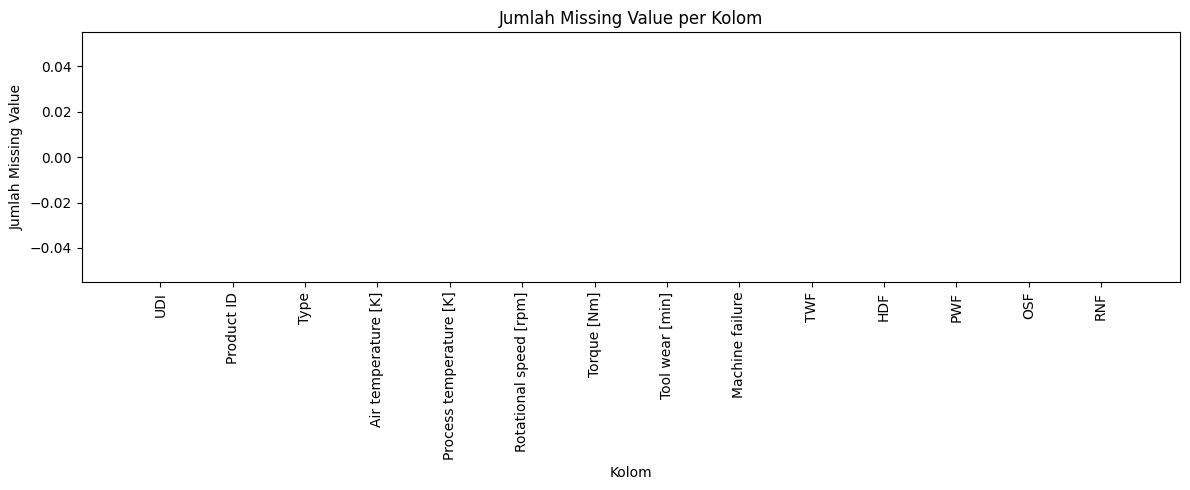

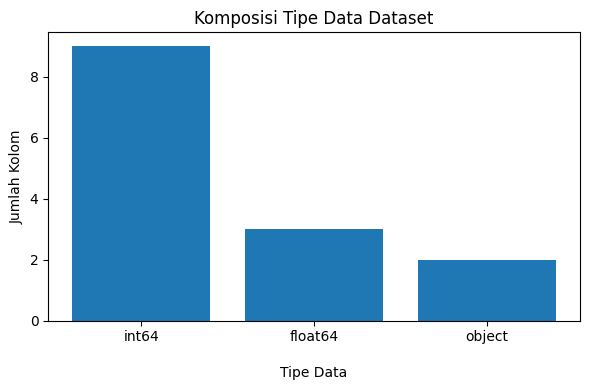

In [ ]:
# Membuat visualisasi jumlah missing value pada setiap kolom
plt.figure(figsize=(12, 5))
plt.bar(missing_values.index, missing_values.values)
plt.xticks(rotation=90)
plt.xlabel("Kolom")
plt.ylabel("Jumlah Missing Value")
plt.title("Jumlah Missing Value per Kolom")
plt.tight_layout()
plt.show()

print("\n")

# Menghitung jumlah kolom berdasarkan tipe data
dtype_counts = df.dtypes.astype(str).value_counts()

# Membuat visualisasi jumlah kolom berdasarkan tipe data
plt.figure(figsize=(6, 4))
plt.bar(dtype_counts.index, dtype_counts.values)
plt.xlabel("\nTipe Data")
plt.ylabel("Jumlah Kolom")
plt.title("Komposisi Tipe Data Dataset")
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis Target

Target yang digunakan adalah `Machine failure`. Nilai 0 menunjukkan kondisi normal, sedangkan nilai 1 menunjukkan kondisi gagal. Analisis distribusi target penting karena kasus predictive maintenance biasanya memiliki jumlah data normal yang jauh lebih besar daripada data gagal.

,Jumlah,Persentase
Machine failure,,
0,9661,96.61
1,339,3.39


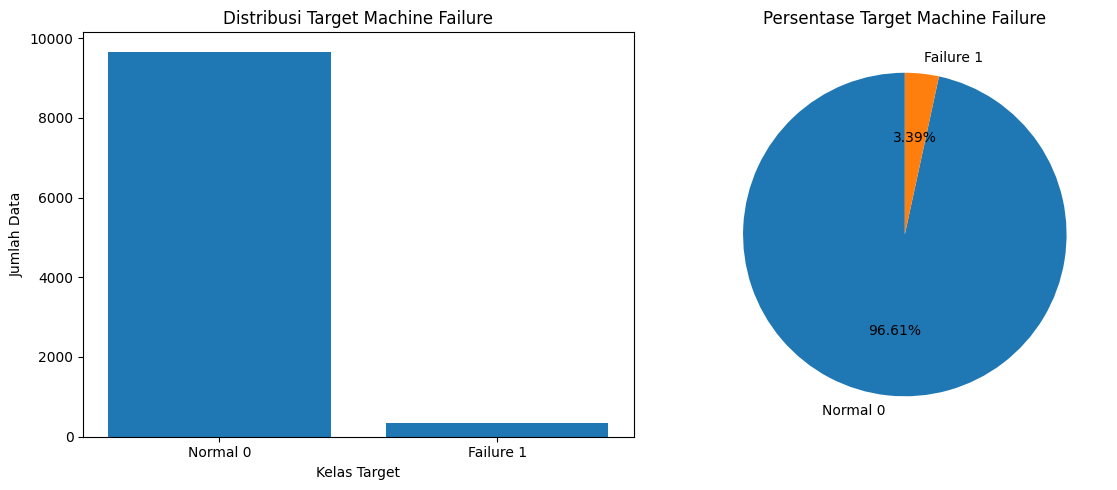

In [ ]:
# Menghitung jumlah masing-masing kelas target
target_counts = df["Machine failure"].value_counts().sort_index()

# Menghitung persentase masing-masing kelas target
target_percentages = df["Machine failure"].value_counts(normalize=True).sort_index() * 100

# Menampilkan jumlah dan persentase target
target_summary = pd.DataFrame({
    "Jumlah": target_counts,
    "Persentase": target_percentages
})

display(target_summary)

# Membuat visualisasi kiri-kanan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart di kiri
axes[0].bar(["Normal 0", "Failure 1"], target_counts.values)
axes[0].set_xlabel("Kelas Target")
axes[0].set_ylabel("Jumlah Data")
axes[0].set_title("Distribusi Target Machine Failure")

# Pie chart di kanan
axes[1].pie(
    target_counts.values,
    labels=["Normal 0", "Failure 1"],
    autopct="%1.2f%%",
    startangle=90
)
axes[1].set_title("Persentase Target Machine Failure")

plt.tight_layout()
plt.show()

## 6. Exploratory Data Analysis Fitur Numerik

Fitur numerik utama yang digunakan berasal dari parameter operasional mesin. Fitur tersebut meliputi suhu udara, suhu proses, kecepatan rotasi, torsi, dan tingkat keausan alat. Histogram digunakan untuk melihat distribusi nilai, sedangkan boxplot digunakan untuk melihat sebaran dan kemungkinan nilai ekstrem.

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


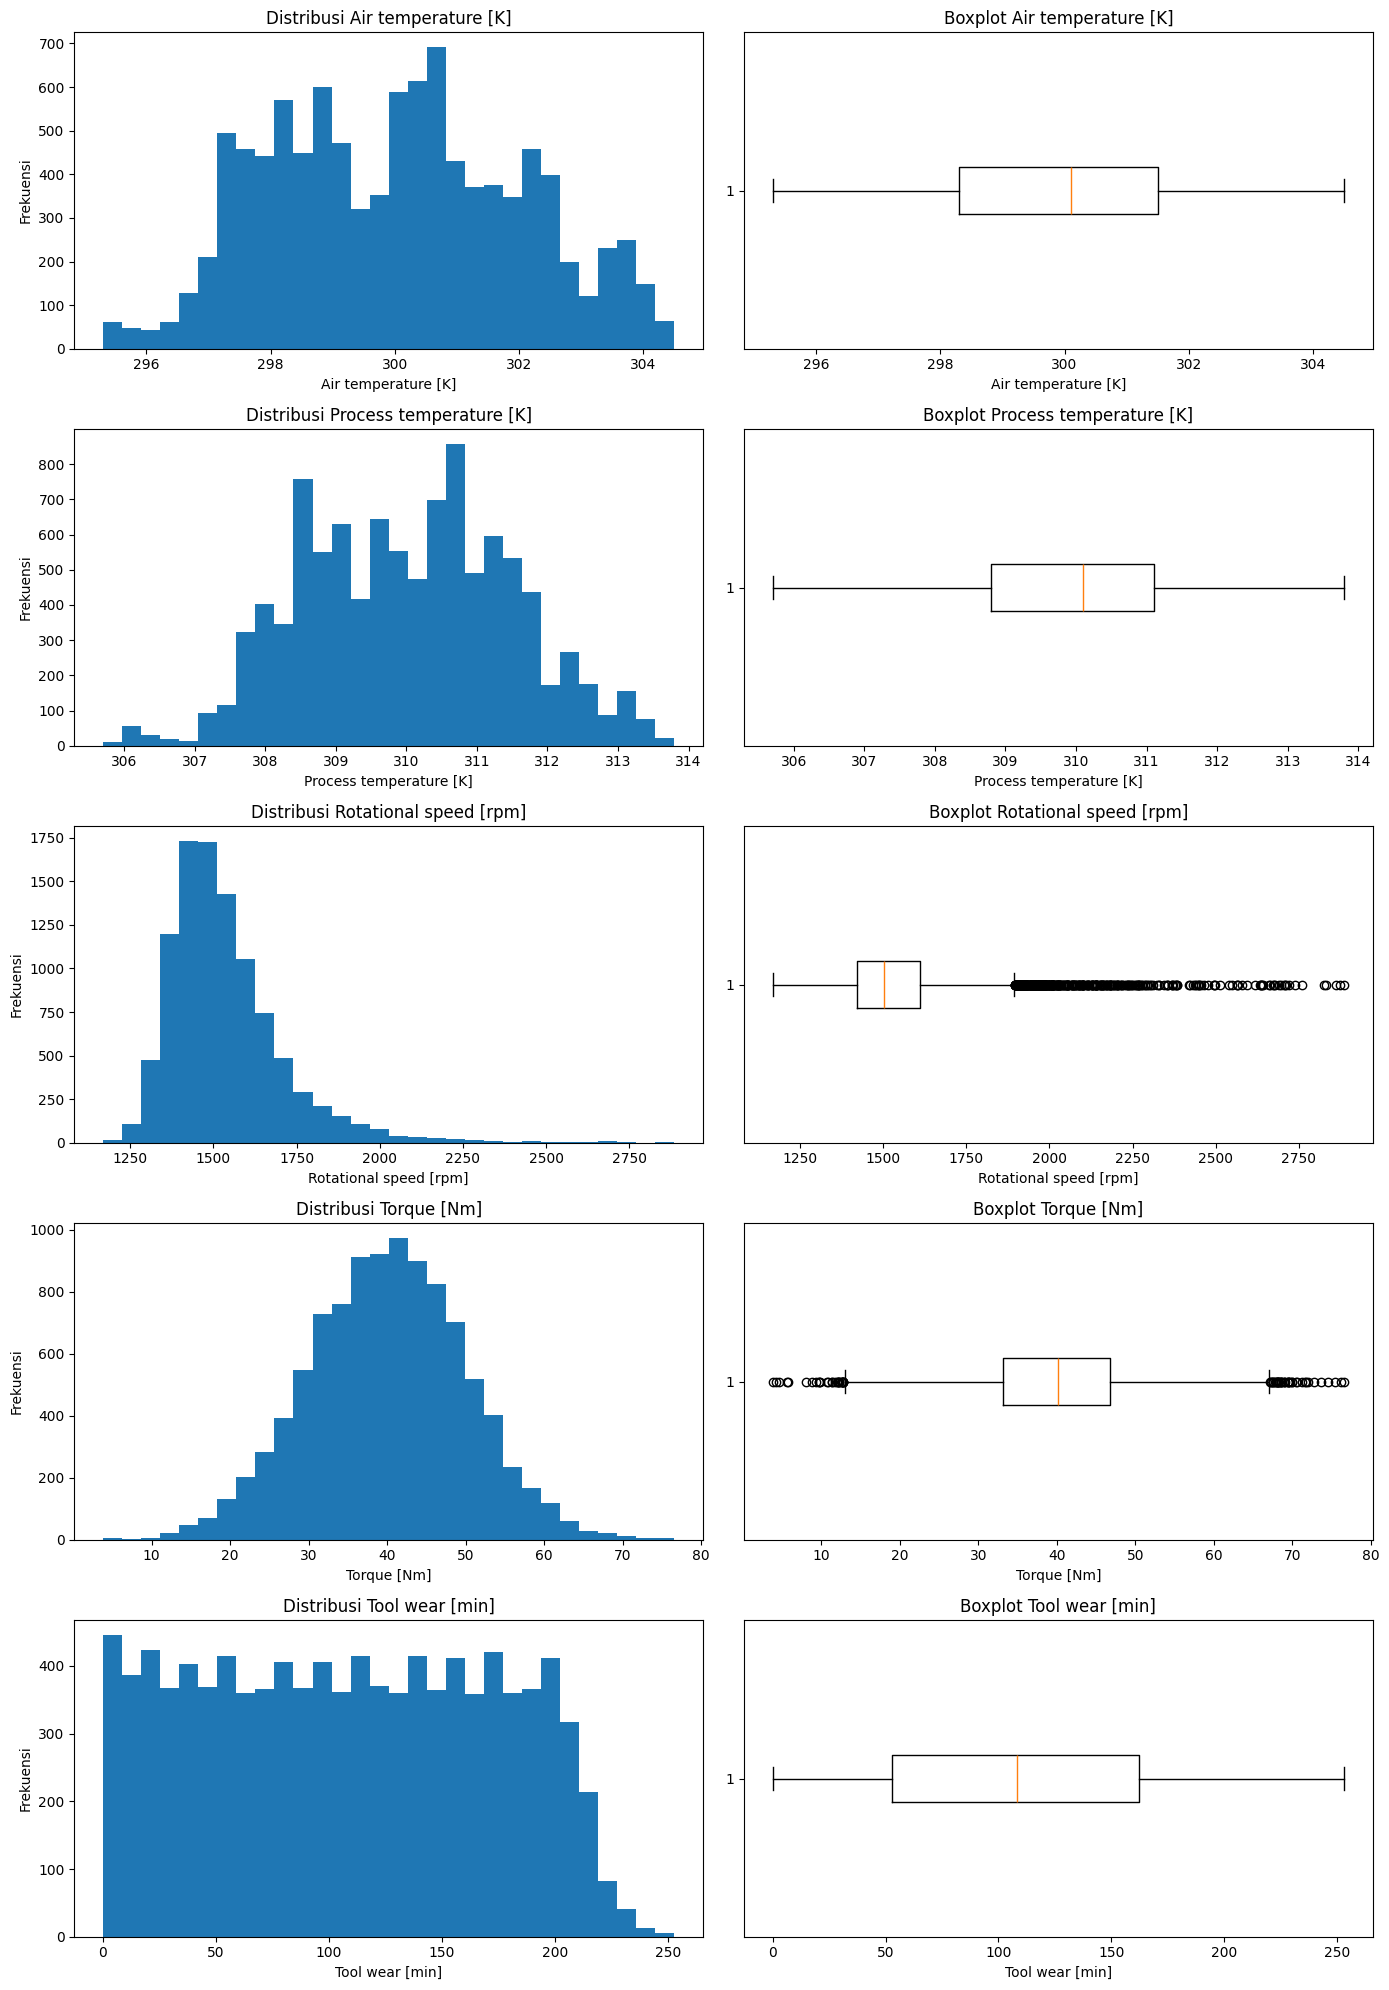

In [ ]:
# Menentukan fitur numerik utama dari dataset
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Menampilkan statistik deskriptif fitur numerik utama
display(df[numeric_features].describe())

# Membuat histogram dan boxplot per fitur secara rapi
fig, axes = plt.subplots(
    nrows=len(numeric_features),
    ncols=2,
    figsize=(14, 4 * len(numeric_features))
)

for i, feature in enumerate(numeric_features):
    # Histogram di kolom kiri
    axes[i, 0].hist(df[feature], bins=30)
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel("Frekuensi")
    axes[i, 0].set_title("Distribusi " + feature)

    # Boxplot di kolom kanan
    axes[i, 1].boxplot(df[feature], vert=False)
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_title("Boxplot " + feature)

plt.tight_layout()
plt.show()

## 7. Analisis Fitur Berdasarkan Target

Analisis ini digunakan untuk membandingkan nilai parameter operasional mesin pada kondisi normal dan kondisi gagal. Perbandingan dilakukan menggunakan rata-rata fitur dan boxplot berdasarkan kelas target.

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


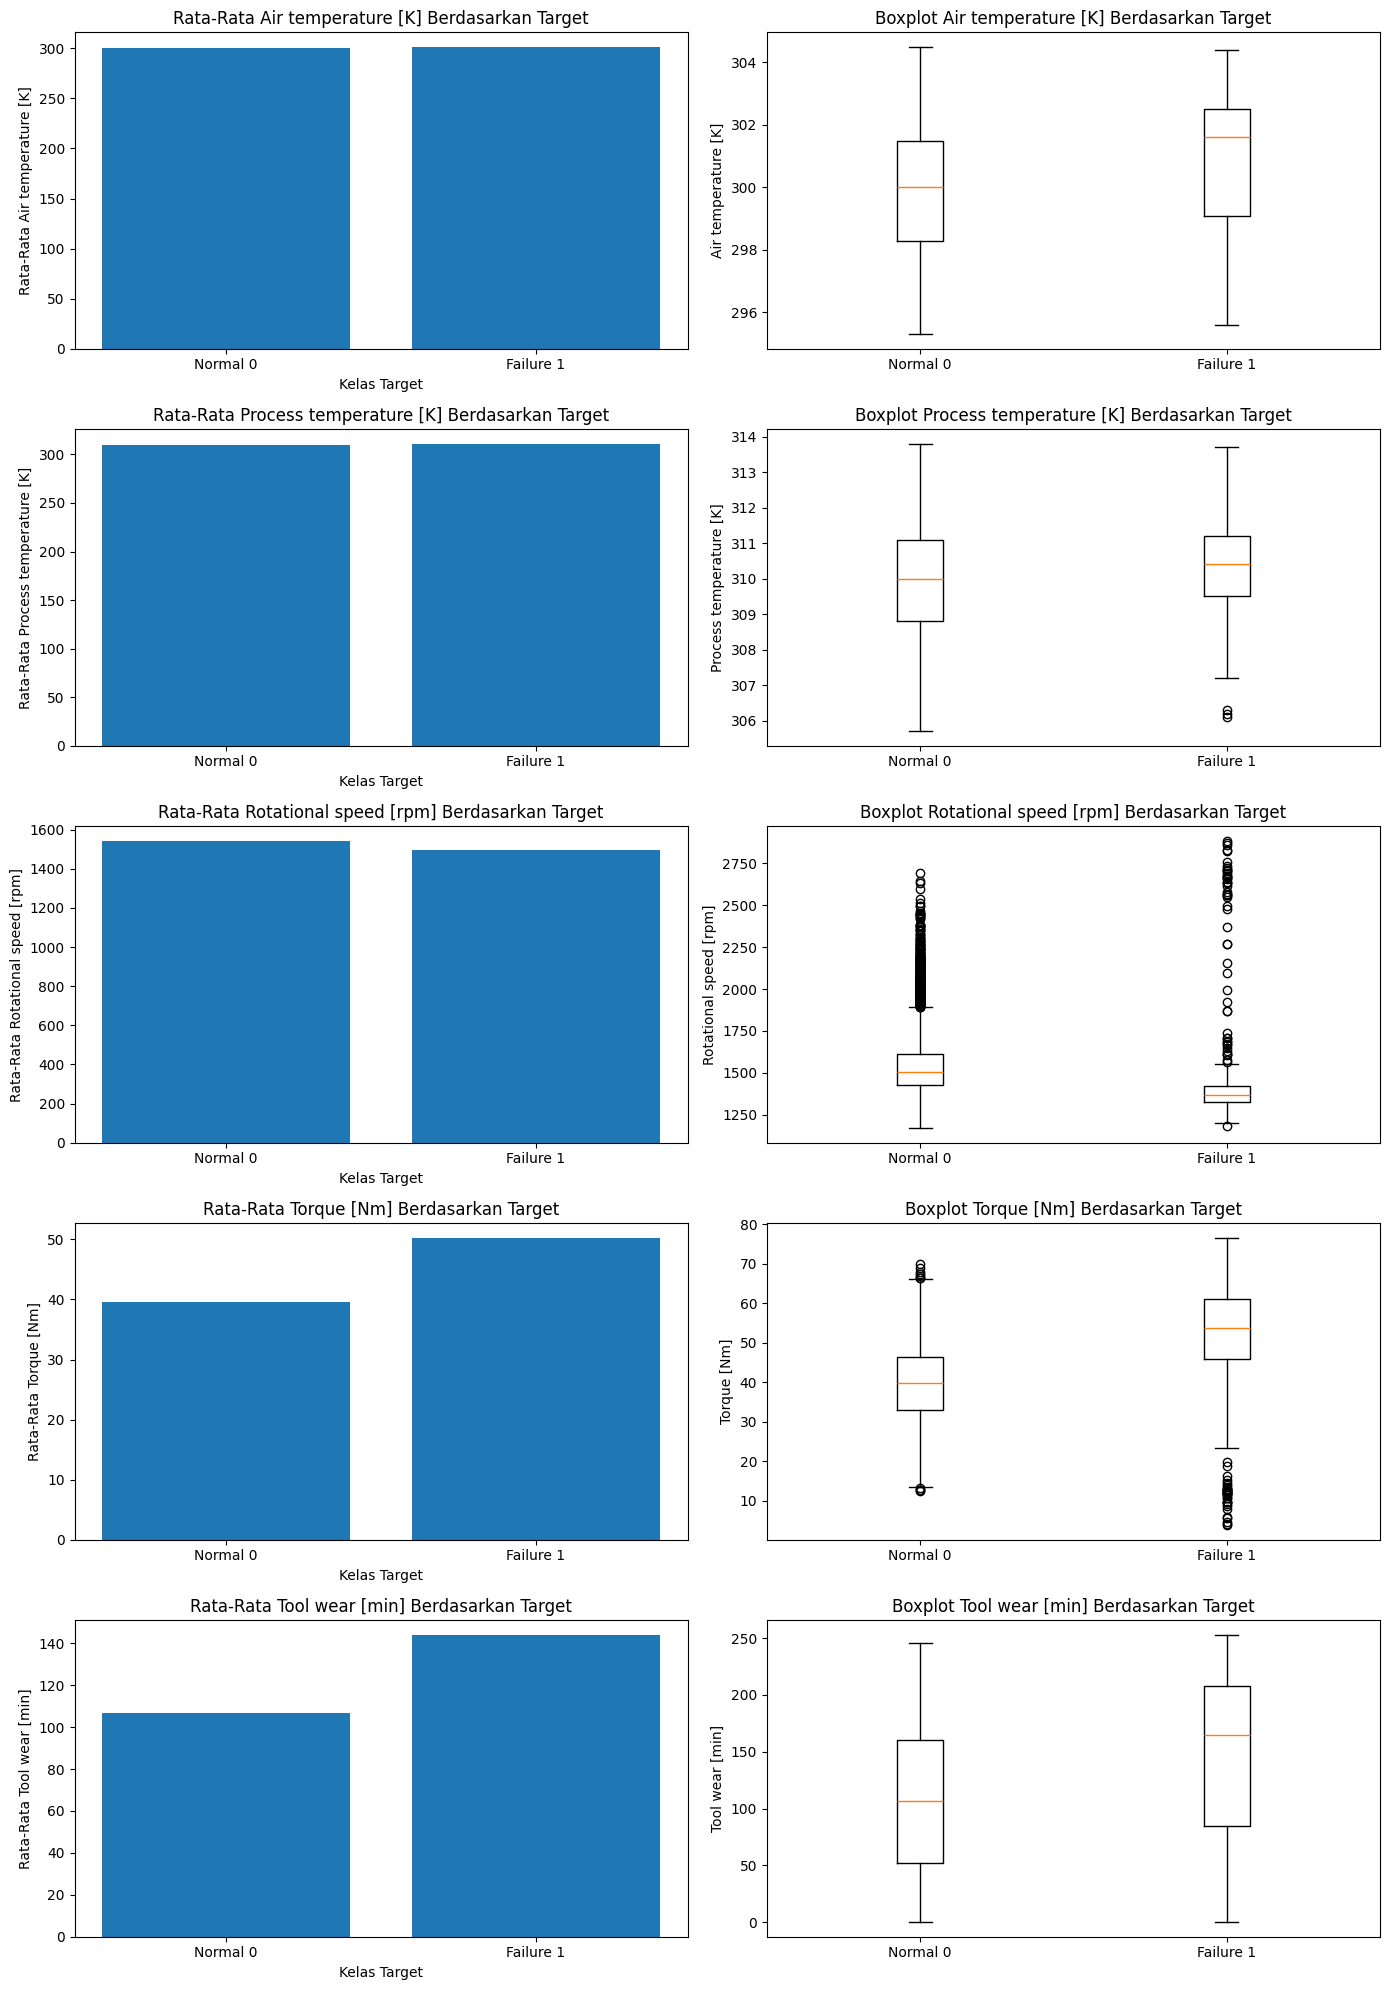

In [ ]:
# Menghitung rata-rata fitur numerik berdasarkan target
feature_mean_by_target = df.groupby("Machine failure")[numeric_features].mean()

# Menampilkan rata-rata fitur numerik berdasarkan target
display(feature_mean_by_target)

# Membuat bar chart rata-rata dan boxplot berdasarkan target secara rapi
fig, axes = plt.subplots(
    nrows=len(numeric_features),
    ncols=2,
    figsize=(14, 4 * len(numeric_features))
)

for i, feature in enumerate(numeric_features):
    # Bar chart rata-rata di kolom kiri
    means = df.groupby("Machine failure")[feature].mean()

    axes[i, 0].bar(["Normal 0", "Failure 1"], means.values)
    axes[i, 0].set_xlabel("Kelas Target")
    axes[i, 0].set_ylabel("Rata-Rata " + feature)
    axes[i, 0].set_title("Rata-Rata " + feature + " Berdasarkan Target")

    # Boxplot berdasarkan target di kolom kanan
    normal_values = df[df["Machine failure"] == 0][feature]
    failure_values = df[df["Machine failure"] == 1][feature]

    axes[i, 1].boxplot(
        [normal_values, failure_values],
        labels=["Normal 0", "Failure 1"]
    )
    axes[i, 1].set_ylabel(feature)
    axes[i, 1].set_title("Boxplot " + feature + " Berdasarkan Target")

plt.tight_layout()
plt.show()

## 8. Korelasi Fitur Numerik

Korelasi digunakan untuk melihat hubungan linear antar fitur numerik dan hubungan fitur dengan target `Machine failure`. Visualisasi heatmap dibuat menggunakan matplotlib agar tidak membutuhkan library tambahan.

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


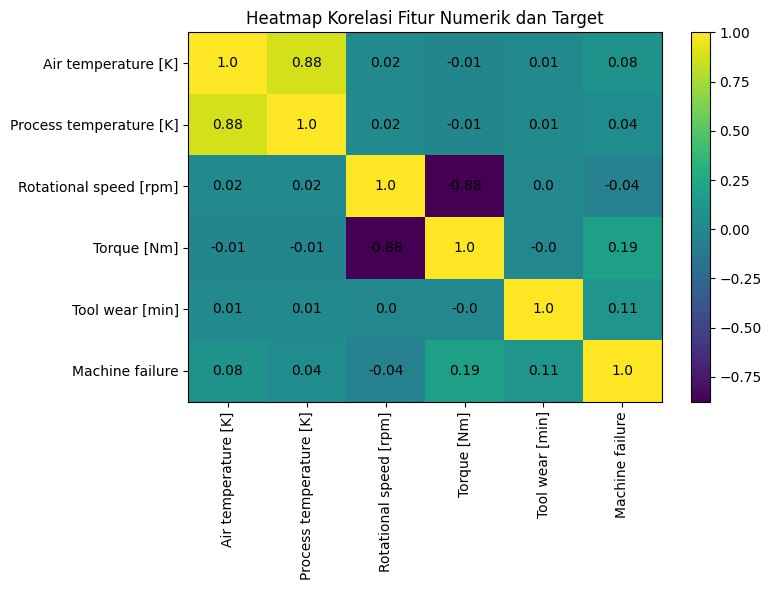

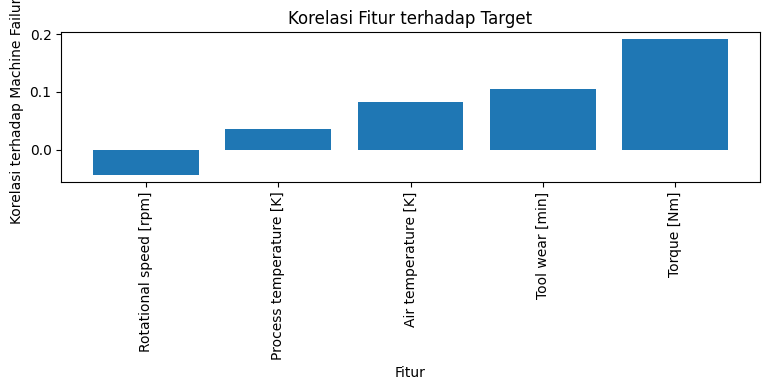

In [ ]:
# Menghitung korelasi fitur numerik dan target
corr_columns = numeric_features + ["Machine failure"]
corr_matrix = df[corr_columns].corr()

# Menampilkan matriks korelasi
display(corr_matrix)

# Membuat heatmap korelasi menggunakan matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Heatmap Korelasi Fitur Numerik dan Target")

# Menambahkan nilai korelasi pada setiap sel
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2), ha="center", va="center")

plt.tight_layout()
plt.show()

# Membuat bar chart korelasi fitur terhadap target
target_corr = corr_matrix["Machine failure"].drop("Machine failure").sort_values()

plt.figure(figsize=(8, 4))
plt.bar(target_corr.index, target_corr.values)
plt.xticks(rotation=90)
plt.xlabel("Fitur")
plt.ylabel("Korelasi terhadap Machine Failure")
plt.title("Korelasi Fitur terhadap Target")
plt.tight_layout()
plt.show()

## 9. Analisis Jenis Failure

Dataset AI4I 2020 memiliki beberapa kolom jenis kegagalan, yaitu `TWF`, `HDF`, `PWF`, `OSF`, dan `RNF`. Kolom-kolom ini hanya digunakan untuk analisis eksploratif, bukan sebagai fitur input model, karena dapat menyebabkan data leakage terhadap target `Machine failure`.

,0
HDF,115
OSF,98
PWF,95
TWF,46
RNF,19


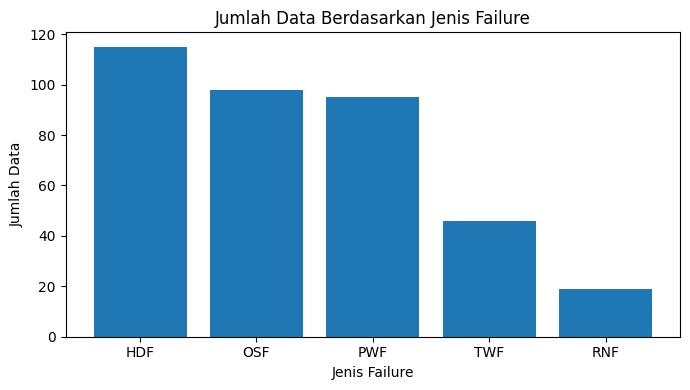

In [ ]:
# Menentukan kolom jenis kegagalan
failure_type_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# Menghitung jumlah masing-masing jenis kegagalan
failure_type_counts = df[failure_type_columns].sum().sort_values(ascending=False)

# Menampilkan jumlah jenis kegagalan
display(failure_type_counts)

# Membuat visualisasi jumlah masing-masing jenis kegagalan
plt.figure(figsize=(7, 4))
plt.bar(failure_type_counts.index, failure_type_counts.values)
plt.xlabel("Jenis Failure")
plt.ylabel("Jumlah Data")
plt.title("Jumlah Data Berdasarkan Jenis Failure")
plt.tight_layout()
plt.show()

## 10. Data Cleaning

Tahap data cleaning dilakukan dengan menghapus kolom yang tidak digunakan sebagai input model. Kolom `UDI` dan `Product ID` dihapus karena hanya berfungsi sebagai identitas data. Kolom `TWF`, `HDF`, `PWF`, `OSF`, dan `RNF` dihapus karena merupakan jenis kegagalan yang berhubungan langsung dengan target. Kolom `Type` dihapus pada tahap awal agar model berfokus pada parameter sensor numerik.

In [ ]:
# Menyimpan daftar kolom sebelum cleaning
columns_before_cleaning = df.columns.tolist()

# Menentukan kolom yang dihapus dari dataset model
columns_to_drop = [
    "UDI",
    "Product ID",
    "Type",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

# Membuat salinan dataset untuk pemodelan
df_model = df.copy()

# Menghapus kolom yang tidak digunakan untuk pemodelan
df_model = df_model.drop(columns=columns_to_drop)

# Menyimpan daftar kolom setelah cleaning
columns_after_cleaning = df_model.columns.tolist()

# Membuat tabel dokumentasi kolom yang dihapus
drop_reason = pd.DataFrame({
    "Kolom Dihapus": columns_to_drop,
    "Alasan": [
        "Nomor urut data dan bukan parameter operasional mesin",
        "Identitas produk dan bukan parameter operasional mesin",
        "Dihapus pada tahap awal agar model fokus pada fitur sensor numerik",
        "Jenis kegagalan dan berisiko menyebabkan data leakage",
        "Jenis kegagalan dan berisiko menyebabkan data leakage",
        "Jenis kegagalan dan berisiko menyebabkan data leakage",
        "Jenis kegagalan dan berisiko menyebabkan data leakage",
        "Jenis kegagalan dan berisiko menyebabkan data leakage"
    ]
})

display(drop_reason)

# Menampilkan lima baris pertama dataset setelah cleaning
display(df_model.head())

,Kolom Dihapus,Alasan
0,UDI,Nomor urut data dan bukan parameter operasiona...
1,Product ID,Identitas produk dan bukan parameter operasion...
2,Type,Dihapus pada tahap awal agar model fokus pada ...
3,TWF,Jenis kegagalan dan berisiko menyebabkan data ...
4,HDF,Jenis kegagalan dan berisiko menyebabkan data ...
5,PWF,Jenis kegagalan dan berisiko menyebabkan data ...
6,OSF,Jenis kegagalan dan berisiko menyebabkan data ...
7,RNF,Jenis kegagalan dan berisiko menyebabkan data ...


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,298.1,308.6,1551,42.8,0,0
1,298.2,308.7,1408,46.3,3,0
2,298.1,308.5,1498,49.4,5,0
3,298.2,308.6,1433,39.5,7,0
4,298.2,308.7,1408,40.0,9,0


## 11. Seleksi Fitur Input dan Target

Tahap ini digunakan untuk menentukan fitur input dan target output yang digunakan dalam pengembangan model. Pada penelitian ini, fitur input yang digunakan hanya berasal dari parameter operasional utama pada dataset AI4I 2020 tanpa melakukan feature engineering.

Fitur input yang digunakan adalah:

* `Air temperature [K]`
* `Process temperature [K]`
* `Rotational speed [rpm]`
* `Torque [Nm]`
* `Tool wear [min]`

Target output yang digunakan adalah:

* `Machine failure`

Kolom `Machine failure` memiliki nilai 0 untuk kondisi normal dan 1 untuk kondisi gagal. Feature engineering tidak dilakukan agar pengembangan model berfokus pada kemampuan ANFIS dan Genetic Algorithm dalam mempelajari pola dari fitur asli dataset.

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,298.1,308.6,1551,42.8,0,0
1,298.2,308.7,1408,46.3,3,0
2,298.1,308.5,1498,49.4,5,0
3,298.2,308.6,1433,39.5,7,0
4,298.2,308.7,1408,40.0,9,0


Ukuran dataset model: (10000, 6)
Fitur input yang digunakan:
Air temperature [K]
Process temperature [K]
Rotational speed [rpm]
Torque [Nm]
Tool wear [min]
Target output: Machine failure


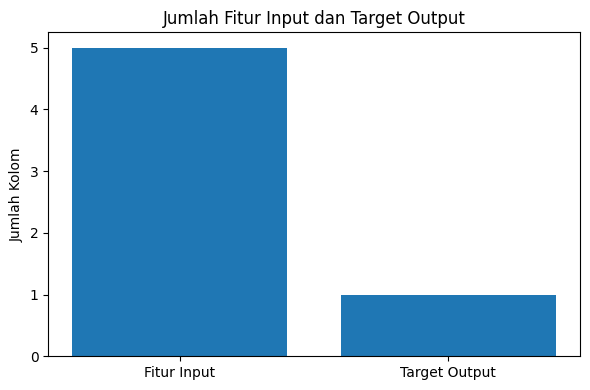

In [ ]:
# Menentukan fitur input utama yang digunakan untuk pengembangan model
selected_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Menentukan target output yang digunakan
target_column = "Machine failure"

# Membuat dataset model hanya dari fitur input utama dan target output
df_model = df_model[selected_features + [target_column]].copy()

# Menampilkan lima baris pertama dataset model
display(df_model.head())

# Menampilkan ukuran dataset model
print("Ukuran dataset model:", df_model.shape)

# Menampilkan daftar fitur input
print("Fitur input yang digunakan:")
for feature in selected_features:
    print(feature)

# Menampilkan target output
print("Target output:", target_column)

# Membuat visualisasi jumlah fitur input dan target output
plt.figure(figsize=(6, 4))
plt.bar(["Fitur Input", "Target Output"], [len(selected_features), 1])
plt.ylabel("Jumlah Kolom")
plt.title("Jumlah Fitur Input dan Target Output")
plt.tight_layout()
plt.show()

## 12. Pemisahan Input dan Output

Tahap ini memisahkan dataset menjadi fitur input `X` dan target output `y`. Fitur input hanya terdiri dari lima parameter operasional utama tanpa feature engineering. Target output yang digunakan adalah `Machine failure`.

In [ ]:
# Memisahkan fitur input dan target output
X = df_model[selected_features].copy()
y = df_model[target_column].astype(int).copy()

# Menyimpan nama fitur input
feature_columns = X.columns.tolist()

# Menampilkan ukuran input dan output
print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

# Menampilkan lima baris pertama fitur input
display(X.head())

# Menampilkan lima data pertama target output
display(y.head())

Ukuran X: (10000, 5)
Ukuran y: (10000,)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


,Machine failure
0,0
1,0
2,0
3,0
4,0


## 13. Normalisasi Data

Normalisasi dilakukan menggunakan MinMaxScaler agar seluruh fitur berada pada rentang 0 sampai 1. Rentang ini memudahkan proses fuzzifikasi karena fungsi keanggotaan fuzzy bekerja lebih stabil pada skala data yang seragam.

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,0.304348,0.358025,0.222934,0.535714,0.000000
1,0.315217,0.370370,0.139697,0.583791,0.011858
2,0.304348,0.345679,0.192084,0.626374,0.019763
3,0.315217,0.358025,0.154249,0.490385,0.027668
4,0.315217,0.370370,0.139697,0.497253,0.035573


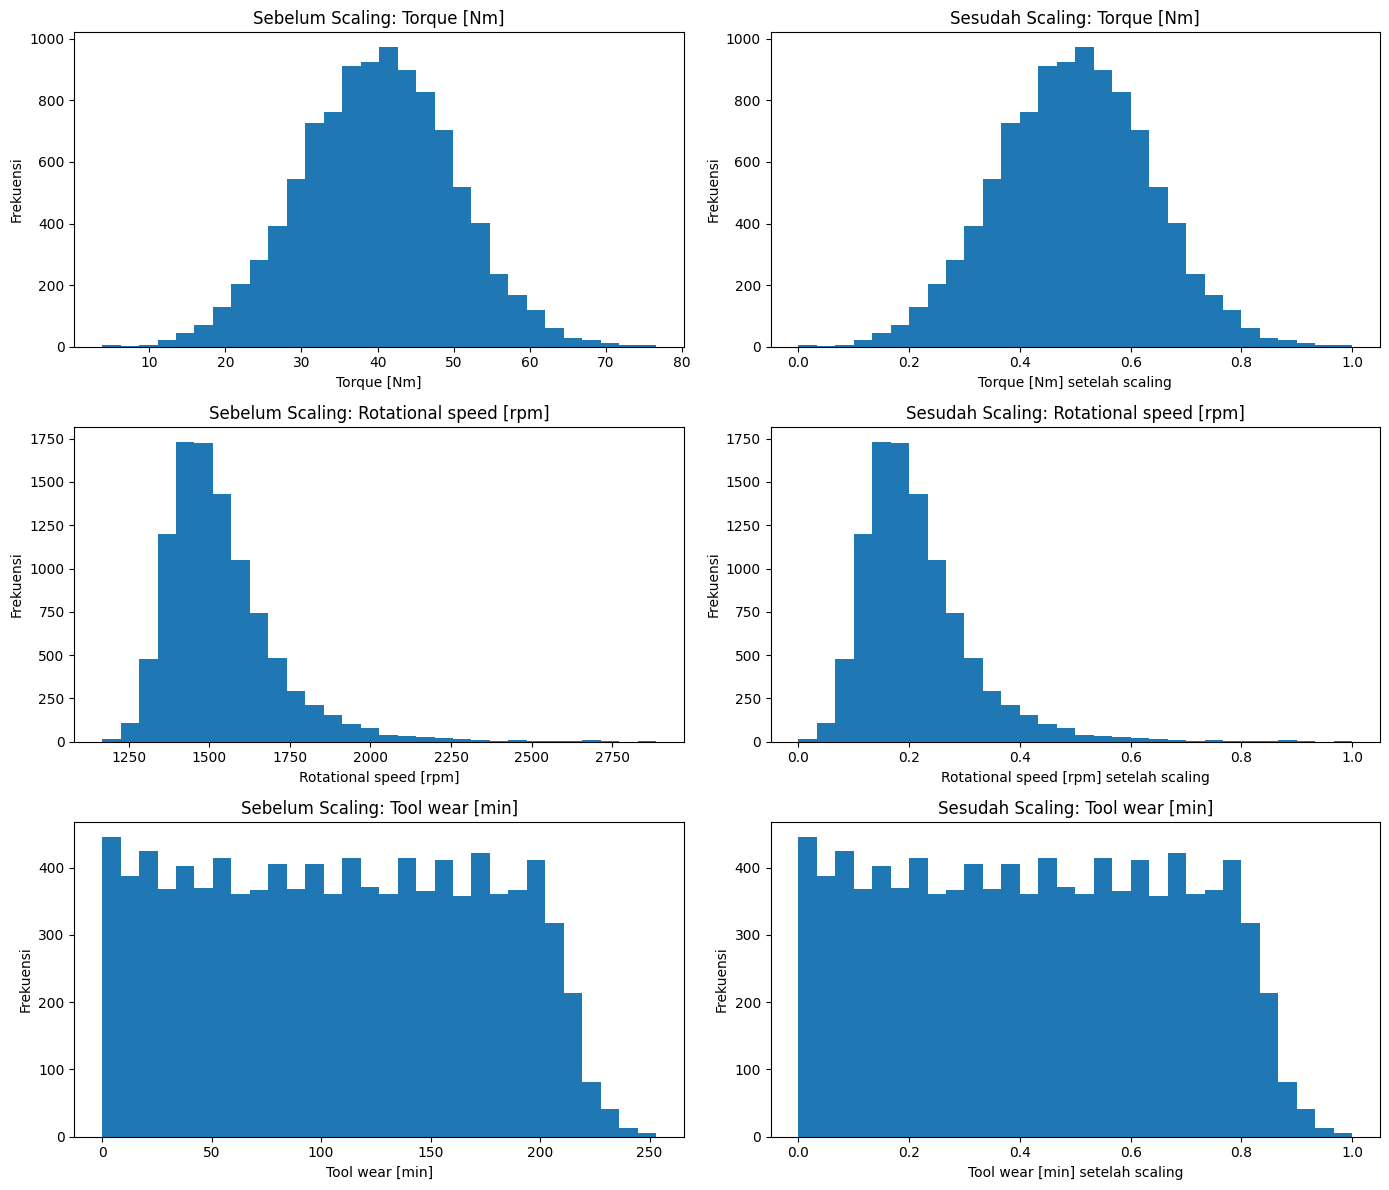

In [ ]:
# Membuat objek MinMaxScaler
scaler = MinMaxScaler()

# Melakukan normalisasi terhadap fitur input
X_scaled = scaler.fit_transform(X)

# Mengubah hasil normalisasi menjadi DataFrame agar mudah dianalisis
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

# Menampilkan lima baris pertama hasil normalisasi
display(X_scaled_df.head())

# Menentukan fitur contoh untuk visualisasi sebelum dan sesudah scaling
sample_features_for_scaling = [
    "Torque [Nm]",
    "Rotational speed [rpm]",
    "Tool wear [min]"
]

# Membuat histogram sebelum dan sesudah scaling secara rapi
fig, axes = plt.subplots(
    nrows=len(sample_features_for_scaling),
    ncols=2,
    figsize=(14, 4 * len(sample_features_for_scaling))
)

for i, feature in enumerate(sample_features_for_scaling):
    # Histogram sebelum scaling di kolom kiri
    axes[i, 0].hist(X[feature], bins=30)
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel("Frekuensi")
    axes[i, 0].set_title("Sebelum Scaling: " + feature)

    # Histogram sesudah scaling di kolom kanan
    axes[i, 1].hist(X_scaled_df[feature], bins=30)
    axes[i, 1].set_xlabel(feature + " setelah scaling")
    axes[i, 1].set_ylabel("Frekuensi")
    axes[i, 1].set_title("Sesudah Scaling: " + feature)

plt.tight_layout()
plt.show()

## 14. Train-Test Split

Dataset dibagi menjadi data latih dan data uji. Stratified split digunakan agar proporsi kelas normal dan failure tetap terjaga pada data latih dan data uji.

Ukuran X_train: (8000, 5)
Ukuran X_test: (2000, 5)
Ukuran y_train: (8000,)
Ukuran y_test: (2000,)


,Train,Test
0,7729,1932
1,271,68


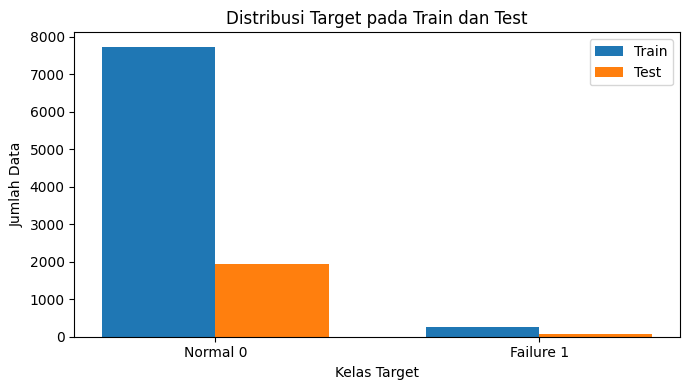

In [ ]:
# Membagi data menjadi data latih dan data uji dengan stratifikasi target
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y.values,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y.values
)

# Menampilkan ukuran data latih dan data uji
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

# Menghitung distribusi target pada data latih dan data uji
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

# Membuat tabel distribusi target
split_distribution = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
})

display(split_distribution)

# Membuat visualisasi distribusi target pada train dan test
x_positions = np.arange(2)
bar_width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x_positions - bar_width / 2, train_counts.values, width=bar_width, label="Train")
plt.bar(x_positions + bar_width / 2, test_counts.values, width=bar_width, label="Test")
plt.xticks(x_positions, ["Normal 0", "Failure 1"])
plt.xlabel("Kelas Target")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Target pada Train dan Test")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Fungsi Bantu untuk ANFIS dan Evaluasi

Bagian ini berisi fungsi-fungsi utama yang digunakan untuk membangun model ANFIS secara manual tanpa library khusus ANFIS. Fungsi yang dibuat meliputi sigmoid, Gaussian membership function, fuzzification, training consequent layer, evaluasi model, visualisasi membership function, visualisasi training loss, dan confusion matrix.

Model menghasilkan nilai keluaran kontinu dari fungsi sigmoid, kemudian nilai tersebut dikonversi menjadi kelas biner 0 atau 1 menggunakan threshold. Target yang digunakan tetap mengikuti dataset, yaitu `Machine failure`.

In [ ]:
# Membuat fungsi sigmoid untuk mengubah output linear menjadi rentang 0 sampai 1
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


# Membuat fungsi Gaussian membership function
def gaussian_membership(x, center, sigma):
    sigma = np.maximum(sigma, 1e-6)
    return np.exp(-((x - center) ** 2) / (2 * sigma ** 2))


# Membuat parameter awal membership function untuk setiap fitur
def initialize_membership_params(n_features):
    centers = np.zeros((n_features, 3))
    sigmas = np.zeros((n_features, 3))

    centers[:, 0] = 0.25
    centers[:, 1] = 0.50
    centers[:, 2] = 0.75

    sigmas[:, 0] = 0.20
    sigmas[:, 1] = 0.20
    sigmas[:, 2] = 0.20

    return centers, sigmas


# Mengubah fitur input menjadi fitur fuzzy berdasarkan membership function
def fuzzify_features(X_input, centers, sigmas):
    n_samples = X_input.shape[0]
    n_features = X_input.shape[1]
    n_memberships = centers.shape[1]

    fuzzy_features = np.zeros((n_samples, n_features * n_memberships))

    column_index = 0
    for feature_index in range(n_features):
        for membership_index in range(n_memberships):
            fuzzy_features[:, column_index] = gaussian_membership(
                X_input[:, feature_index],
                centers[feature_index, membership_index],
                sigmas[feature_index, membership_index]
            )
            column_index += 1

    return fuzzy_features


# Menghitung binary cross entropy loss dengan pembobotan kelas positif
def weighted_binary_cross_entropy(y_true, y_prob, positive_weight):
    epsilon = 1e-8
    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)
    sample_weights = np.where(y_true == 1, positive_weight, 1.0)
    loss = -np.mean(sample_weights * (y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob)))
    return loss


# Melatih consequent layer ANFIS menggunakan gradient descent
def train_consequent_layer(
    fuzzy_train,
    y_train_input,
    fuzzy_val=None,
    y_val_input=None,
    epochs=400,
    learning_rate=0.05,
    threshold=0.5,
    verbose=False
):
    n_fuzzy_features = fuzzy_train.shape[1]
    weights = np.zeros(n_fuzzy_features)
    bias = 0.0

    # Karena data training sudah diseimbangkan menggunakan SMOTE, class weight dibuat netral
    positive_weight = 1.0

    history = {
        "loss": [],
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": []
    }

    for epoch in range(epochs):
        linear_output = np.dot(fuzzy_train, weights) + bias
        output_value = sigmoid(linear_output)

        sample_weights = np.where(y_train_input == 1, positive_weight, 1.0)
        gradient_common = (output_value - y_train_input) * sample_weights

        grad_weights = np.dot(fuzzy_train.T, gradient_common) / np.sum(sample_weights)
        grad_bias = np.sum(gradient_common) / np.sum(sample_weights)

        weights = weights - learning_rate * grad_weights
        bias = bias - learning_rate * grad_bias

        train_loss = weighted_binary_cross_entropy(y_train_input, output_value, positive_weight)
        train_pred = (output_value >= threshold).astype(int)

        history["loss"].append(train_loss)
        history["accuracy"].append(accuracy_score(y_train_input, train_pred))
        history["precision"].append(precision_score(y_train_input, train_pred, zero_division=0))
        history["recall"].append(recall_score(y_train_input, train_pred, zero_division=0))
        history["f1"].append(f1_score(y_train_input, train_pred, zero_division=0))

        if fuzzy_val is not None and y_val_input is not None:
            val_output = sigmoid(np.dot(fuzzy_val, weights) + bias)
            val_loss = weighted_binary_cross_entropy(y_val_input, val_output, positive_weight)
            val_pred = (val_output >= threshold).astype(int)

            history["val_loss"].append(val_loss)
            history["val_accuracy"].append(accuracy_score(y_val_input, val_pred))
            history["val_precision"].append(precision_score(y_val_input, val_pred, zero_division=0))
            history["val_recall"].append(recall_score(y_val_input, val_pred, zero_division=0))
            history["val_f1"].append(f1_score(y_val_input, val_pred, zero_division=0))

        if verbose and (epoch + 1) % 100 == 0:
            print("Epoch:", epoch + 1, "Loss:", train_loss, "F1:", history["f1"][-1])

    return weights, bias, history


# Menghasilkan output model ANFIS
def predict_output(X_input, centers, sigmas, weights, bias):
    fuzzy_input = fuzzify_features(X_input, centers, sigmas)
    output_value = sigmoid(np.dot(fuzzy_input, weights) + bias)
    return output_value


# Mengubah output model menjadi kelas biner
def output_to_class(output_value, threshold=0.5):
    return (output_value >= threshold).astype(int)


# Mengevaluasi hasil klasifikasi model
def evaluate_model(y_true, output_value, threshold=0.5):
    y_pred = output_to_class(output_value, threshold)

    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

    try:
        result["ROC-AUC"] = roc_auc_score(y_true, output_value)
    except:
        result["ROC-AUC"] = np.nan

    return result, y_pred


# Membuat parameter membership function berdasarkan distribusi data train
def initialize_membership_params_from_data(X_input):
    n_features = X_input.shape[1]

    centers = np.zeros((n_features, 3))
    sigmas = np.zeros((n_features, 3))

    for feature_index in range(n_features):
        feature_values = X_input[:, feature_index]

        q25 = np.percentile(feature_values, 25)
        q50 = np.percentile(feature_values, 50)
        q75 = np.percentile(feature_values, 75)

        centers[feature_index, 0] = q25
        centers[feature_index, 1] = q50
        centers[feature_index, 2] = q75

        iqr = q75 - q25

        if iqr < 0.10:
            sigma_value = 0.10
        else:
            sigma_value = iqr / 2

        sigmas[feature_index, 0] = sigma_value
        sigmas[feature_index, 1] = sigma_value
        sigmas[feature_index, 2] = sigma_value

    return centers, sigmas


# Mencari threshold terbaik berdasarkan F1-score pada validation set
def find_best_threshold(y_true, output_value):
    thresholds = np.arange(0.01, 0.99, 0.01)

    best_threshold = 0.5
    best_f1 = 0

    for threshold in thresholds:
        y_pred = output_to_class(output_value, threshold)
        current_f1 = f1_score(y_true, y_pred, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    return best_threshold, best_f1

# Membuat visualisasi membership function untuk satu fitur
def plot_membership_function_for_feature(feature_name, centers, sigmas, feature_index, title):
    x_values = np.linspace(0, 1, 300)

    low_values = gaussian_membership(x_values, centers[feature_index, 0], sigmas[feature_index, 0])
    medium_values = gaussian_membership(x_values, centers[feature_index, 1], sigmas[feature_index, 1])
    high_values = gaussian_membership(x_values, centers[feature_index, 2], sigmas[feature_index, 2])

    plt.figure(figsize=(7, 4))
    plt.plot(x_values, low_values, label="Low")
    plt.plot(x_values, medium_values, label="Medium")
    plt.plot(x_values, high_values, label="High")
    plt.xlabel("Nilai Fitur Setelah Normalisasi")
    plt.ylabel("Derajat Keanggotaan")
    plt.title(title + " - " + feature_name)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Membuat visualisasi membership function untuk beberapa fitur terpilih
def plot_membership_functions(centers, sigmas, feature_columns_input, selected_features, title):
    for feature_name in selected_features:
        feature_index = feature_columns_input.index(feature_name)
        plot_membership_function_for_feature(feature_name, centers, sigmas, feature_index, title)


# Membuat visualisasi training loss
def plot_training_loss(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history["loss"], label="Train Loss")
    if len(history["val_loss"]) > 0:
        plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Membuat visualisasi confusion matrix
def plot_confusion_matrix_result(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, aspect="auto")
    plt.colorbar()
    plt.xticks([0, 1], ["Prediksi 0", "Prediksi 1"])
    plt.yticks([0, 1], ["Aktual 0", "Aktual 1"])
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.title(title)

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()


# Membuat visualisasi perbandingan metrik evaluasi
def plot_metric_comparison(comparison_df, metric_names):
    x_positions = np.arange(len(metric_names))
    bar_width = 0.35

    model_1_values = comparison_df.loc[comparison_df["Model"] == "ANFIS Tanpa GA", metric_names].values.flatten()
    model_2_values = comparison_df.loc[comparison_df["Model"] == "ANFIS dengan GA", metric_names].values.flatten()

    plt.figure(figsize=(10, 5))
    plt.bar(x_positions - bar_width / 2, model_1_values, width=bar_width, label="ANFIS Tanpa GA")
    plt.bar(x_positions + bar_width / 2, model_2_values, width=bar_width, label="ANFIS dengan GA")
    plt.xticks(x_positions, metric_names)
    plt.ylim(0, 1)
    plt.ylabel("Skor")
    plt.title("Perbandingan Performa Model")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 16. Membership Function Awal

Pada tahap awal, parameter membership function ditentukan secara manual. Setiap fitur memiliki tiga fungsi keanggotaan, yaitu low, medium, dan high. Karena fitur telah dinormalisasi ke rentang 0 sampai 1, center awal ditentukan pada 0.25, 0.50, dan 0.75, sedangkan sigma awal ditentukan sebesar 0.20.

,Feature,Membership,Center,Sigma
0,Air temperature [K],Low,0.326087,0.173913
1,Air temperature [K],Medium,0.521739,0.173913
2,Air temperature [K],High,0.673913,0.173913
3,Process temperature [K],Low,0.382716,0.141975
4,Process temperature [K],Medium,0.543210,0.141975
5,Process temperature [K],High,0.666667,0.141975
6,Rotational speed [rpm],Low,0.147846,0.055588
7,Rotational speed [rpm],Medium,0.194994,0.055588
8,Rotational speed [rpm],High,0.259022,0.055588
9,Torque [Nm],Low,0.403846,0.093407


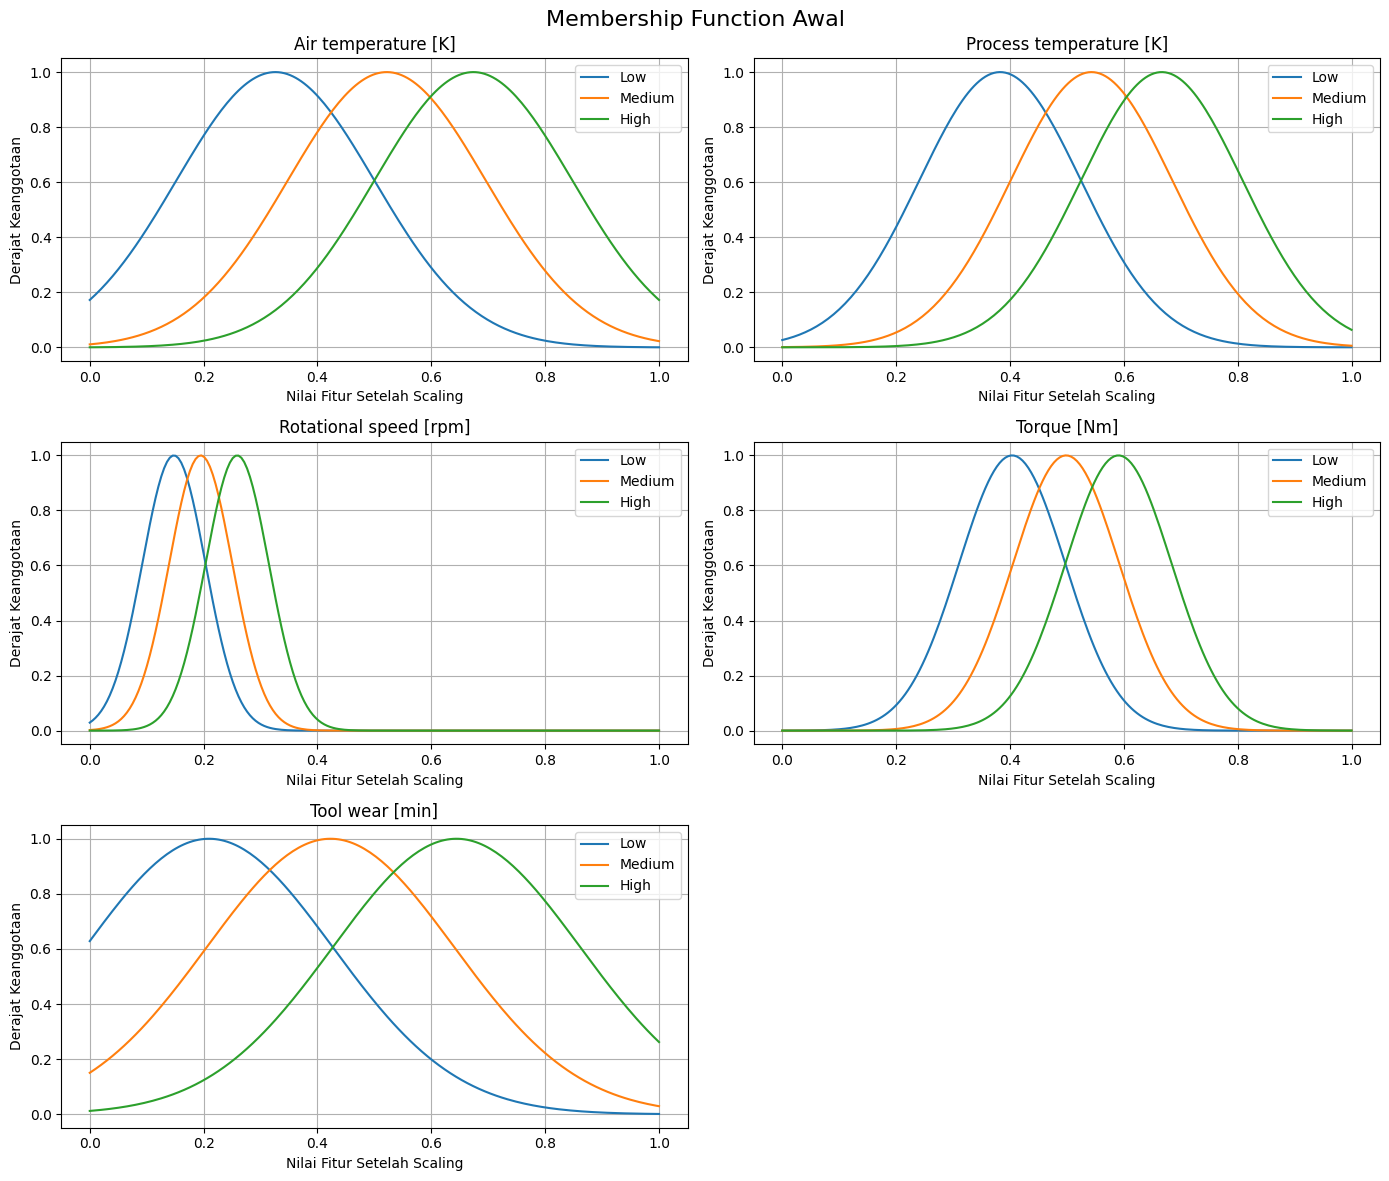

In [ ]:
# Menghitung jumlah fitur input
n_input_features = X_train.shape[1]

# Menginisialisasi parameter membership function awal berdasarkan distribusi data train
initial_centers, initial_sigmas = initialize_membership_params_from_data(X_train)

# Membuat tabel parameter membership function awal
initial_mf_table = pd.DataFrame({
    "Feature": np.repeat(feature_columns, 3),
    "Membership": ["Low", "Medium", "High"] * len(feature_columns),
    "Center": initial_centers.flatten(),
    "Sigma": initial_sigmas.flatten()
})

# Menampilkan parameter membership function awal
display(initial_mf_table)

# Menentukan fitur utama yang divisualisasikan
selected_membership_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Membuat visualisasi membership function awal secara rapi dalam kolom
n_cols = 2
n_rows = int(np.ceil(len(selected_membership_features) / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

x = np.linspace(0, 1, 200)

for i, feature in enumerate(selected_membership_features):
    feature_index = feature_columns.index(feature)

    low = np.exp(-((x - initial_centers[feature_index, 0]) ** 2) / (2 * initial_sigmas[feature_index, 0] ** 2))
    medium = np.exp(-((x - initial_centers[feature_index, 1]) ** 2) / (2 * initial_sigmas[feature_index, 1] ** 2))
    high = np.exp(-((x - initial_centers[feature_index, 2]) ** 2) / (2 * initial_sigmas[feature_index, 2] ** 2))

    axes[i].plot(x, low, label="Low")
    axes[i].plot(x, medium, label="Medium")
    axes[i].plot(x, high, label="High")

    axes[i].set_title(feature)
    axes[i].set_xlabel("Nilai Fitur Setelah Scaling")
    axes[i].set_ylabel("Derajat Keanggotaan")
    axes[i].legend()
    axes[i].grid(True)

# Menghapus subplot kosong jika jumlah fitur ganjil
for j in range(len(selected_membership_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Membership Function Awal", fontsize=16)
plt.tight_layout()
plt.show()

## 17. Fuzzification Data

Fuzzification digunakan untuk mengubah fitur input numerik menjadi derajat keanggotaan fuzzy. Setiap fitur menghasilkan tiga nilai keanggotaan, yaitu low, medium, dan high. Hasil fuzzification ini menjadi input untuk consequent layer ANFIS.

In [ ]:
# Melakukan fuzzification pada data train dan data test menggunakan parameter awal
fuzzy_train_initial = fuzzify_features(X_train, initial_centers, initial_sigmas)
fuzzy_test_initial = fuzzify_features(X_test, initial_centers, initial_sigmas)

# Menampilkan ukuran data sebelum dan sesudah fuzzification
print("Ukuran X_train:", X_train.shape)
print("Ukuran fuzzy_train_initial:", fuzzy_train_initial.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran fuzzy_test_initial:", fuzzy_test_initial.shape)

Ukuran X_train: (8000, 5)
Ukuran fuzzy_train_initial: (8000, 15)
Ukuran X_test: (2000, 5)
Ukuran fuzzy_test_initial: (2000, 15)


## 18. Training ANFIS Tanpa Genetic Algorithm

Pada model ANFIS tanpa GA, parameter membership function tidak dioptimasi. Center dan sigma tetap menggunakan nilai awal. Proses training dilakukan pada bobot consequent layer dan bias menggunakan gradient descent.

Distribusi y_train_inner sebelum SMOTE:


,count
0,6183
1,217


Distribusi y_val_inner asli:


,count
0,1546
1,54


Distribusi y_train_inner setelah SMOTE:


,count
0,6183
1,2164


Epoch: 100 Loss: 0.4779682902743502 F1: 0.0
Epoch: 200 Loss: 0.44119141831536757 F1: 0.07209612817089453
Epoch: 300 Loss: 0.41850187037681447 F1: 0.2970373220469411
Epoch: 400 Loss: 0.4032667502296063 F1: 0.46680080482897385
Epoch: 500 Loss: 0.3923353252877262 F1: 0.5345420443888715
Epoch: 600 Loss: 0.3840782808171962 F1: 0.5772212283840191
Epoch: 700 Loss: 0.3775861508773706 F1: 0.6028266512835304
Epoch: 800 Loss: 0.3723174019921963 F1: 0.6347705146036161
Epoch: 900 Loss: 0.3679317165156703 F1: 0.6503534529635672
Epoch: 1000 Loss: 0.36420534693247664 F1: 0.6591397849462366


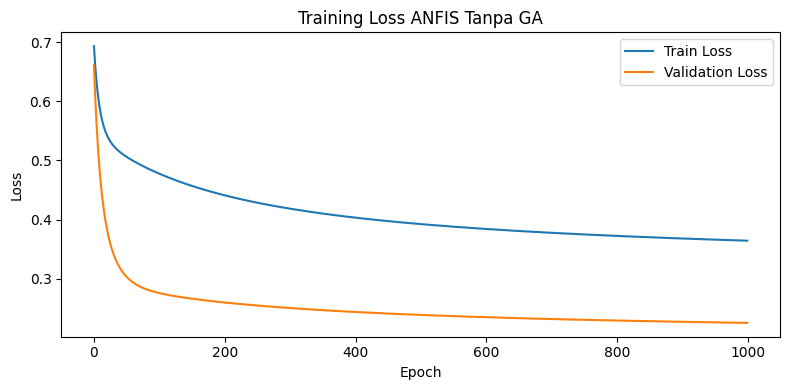

Best Threshold ANFIS Tanpa GA: 0.54
Best Validation F1 ANFIS Tanpa GA: 0.34532374100719426


In [ ]:
# Membagi data train asli menjadi train internal dan validation internal
# Split ini akan dipakai bersama oleh ANFIS tanpa GA dan ANFIS dengan GA agar perbandingan adil
X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

# Menampilkan distribusi data train internal sebelum SMOTE
print("Distribusi y_train_inner sebelum SMOTE:")
display(pd.Series(y_train_inner).value_counts().sort_index())

# Menampilkan distribusi data validation internal
# Validation tidak boleh terkena SMOTE agar evaluasi threshold tetap realistis
print("Distribusi y_val_inner asli:")
display(pd.Series(y_val_inner).value_counts().sort_index())

# Menerapkan SMOTE hanya pada train internal
# sampling_strategy=0.35 berarti jumlah kelas failure dibuat sekitar 35% dari jumlah kelas normal
# Ini lebih aman daripada SMOTE 1:1 karena dataset asli sangat imbalance
smote_without_ga = SMOTE(
    sampling_strategy=0.35,
    random_state=RANDOM_STATE,
    k_neighbors=5
)

X_train_inner_smote, y_train_inner_smote = smote_without_ga.fit_resample(
    X_train_inner,
    y_train_inner
)

# Menampilkan distribusi data train internal setelah SMOTE
print("Distribusi y_train_inner setelah SMOTE:")
display(pd.Series(y_train_inner_smote).value_counts().sort_index())

# Melakukan fuzzification pada train hasil SMOTE dan validation asli
fuzzy_train_inner_initial = fuzzify_features(
    X_train_inner_smote,
    initial_centers,
    initial_sigmas
)

fuzzy_val_inner_initial = fuzzify_features(
    X_val_inner,
    initial_centers,
    initial_sigmas
)

# Menentukan parameter training ANFIS tanpa GA
epochs_without_ga = 1000
learning_rate_without_ga = 0.05
threshold_without_ga = 0.5

# Melatih consequent layer ANFIS tanpa GA
# Data train menggunakan hasil SMOTE
# Data validation tetap menggunakan data asli
weights_without_ga, bias_without_ga, history_without_ga = train_consequent_layer(
    fuzzy_train_inner_initial,
    y_train_inner_smote,
    fuzzy_val=fuzzy_val_inner_initial,
    y_val_input=y_val_inner,
    epochs=epochs_without_ga,
    learning_rate=learning_rate_without_ga,
    threshold=threshold_without_ga,
    verbose=True
)

# Menampilkan visualisasi training loss ANFIS tanpa GA
plot_training_loss(
    history_without_ga,
    "Training Loss ANFIS Tanpa GA"
)

# Menghasilkan output validation untuk mencari threshold terbaik
val_output_without_ga = predict_output(
    X_val_inner,
    initial_centers,
    initial_sigmas,
    weights_without_ga,
    bias_without_ga
)

# Mencari threshold terbaik berdasarkan F1-score pada validation asli
best_threshold_without_ga, best_val_f1_without_ga = find_best_threshold(
    y_val_inner,
    val_output_without_ga
)

# Menggunakan threshold terbaik dari validation asli untuk evaluasi akhir
threshold_without_ga = best_threshold_without_ga

print("Best Threshold ANFIS Tanpa GA:", threshold_without_ga)
print("Best Validation F1 ANFIS Tanpa GA:", best_val_f1_without_ga)

## 19. Evaluasi ANFIS Tanpa Genetic Algorithm

Evaluasi dilakukan menggunakan data test. Output model dikonversi menjadi kelas biner 0 atau 1 menggunakan threshold terbaik dari validation set. Metrik evaluasi yang digunakan adalah accuracy, precision, recall, F1-score, ROC-AUC, classification report, dan confusion matrix.

Metrik Evaluasi ANFIS Tanpa GA:


,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.9445,0.287129,0.426471,0.343195,0.904861


Classification Report ANFIS Tanpa GA:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1932
           1       0.29      0.43      0.34        68

    accuracy                           0.94      2000
   macro avg       0.63      0.69      0.66      2000
weighted avg       0.96      0.94      0.95      2000



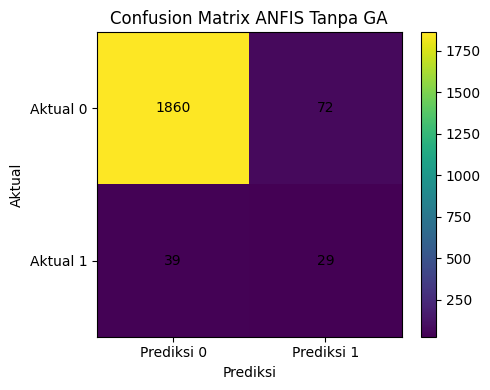

In [ ]:
# Menghasilkan output model pada data test menggunakan ANFIS tanpa GA
output_without_ga = predict_output(
    X_test,
    initial_centers,
    initial_sigmas,
    weights_without_ga,
    bias_without_ga
)

# Mengevaluasi model ANFIS tanpa GA
metrics_without_ga, y_pred_without_ga = evaluate_model(
    y_test,
    output_without_ga,
    threshold=threshold_without_ga
)

# Menampilkan metrik evaluasi ANFIS tanpa GA
print("Metrik Evaluasi ANFIS Tanpa GA:")
display(pd.DataFrame([metrics_without_ga]))

# Menampilkan classification report
print("Classification Report ANFIS Tanpa GA:")
print(classification_report(y_test, y_pred_without_ga, zero_division=0))

# Menampilkan confusion matrix ANFIS tanpa GA
plot_confusion_matrix_result(
    y_test,
    y_pred_without_ga,
    "Confusion Matrix ANFIS Tanpa GA"
)

## 20. Analisis Threshold ANFIS Tanpa Genetic Algorithm

Bagian ini digunakan untuk melihat pengaruh perubahan threshold terhadap precision, recall, dan F1-score. Analisis threshold penting karena dataset memiliki distribusi kelas yang tidak seimbang, sehingga threshold 0.5 belum tentu menjadi threshold terbaik untuk mendeteksi kelas failure.

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.05,0.3215,0.047719,1.000000,0.091092
1,0.10,0.5415,0.068159,0.985294,0.127498
2,0.15,0.6325,0.080503,0.941176,0.148320
3,0.20,0.7105,0.098901,0.926471,0.178723
4,0.25,0.7685,0.117988,0.897059,0.208547
5,0.30,0.8115,0.133017,0.823529,0.229039
6,0.35,0.8520,0.162722,0.808824,0.270936
7,0.40,0.8920,0.204000,0.750000,0.320755
8,0.45,0.9100,0.208333,0.588235,0.307692
9,0.50,0.9245,0.221477,0.485294,0.304147


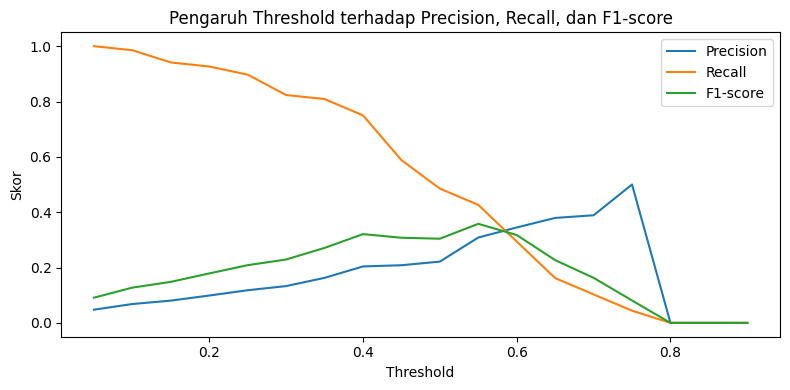

In [ ]:
# Membuat daftar threshold yang akan diuji
threshold_list = np.arange(0.05, 0.95, 0.05)

# Menyimpan hasil evaluasi untuk setiap threshold
threshold_results = []

# Melakukan evaluasi model pada berbagai threshold
for threshold in threshold_list:
    y_pred_threshold = output_to_class(output_without_ga, threshold)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

# Mengubah hasil threshold menjadi DataFrame
threshold_results_df = pd.DataFrame(threshold_results)

# Menampilkan tabel hasil threshold
display(threshold_results_df)

# Membuat visualisasi pengaruh threshold terhadap precision, recall, dan F1-score
plt.figure(figsize=(8, 4))
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1-score"], label="F1-score")
plt.xlabel("Threshold")
plt.ylabel("Skor")
plt.title("Pengaruh Threshold terhadap Precision, Recall, dan F1-score")
plt.legend()
plt.tight_layout()
plt.show()

## 21. Fungsi Genetic Algorithm

Bagian ini berisi fungsi-fungsi Genetic Algorithm yang digunakan untuk mengoptimasi parameter ANFIS. Parameter yang dioptimasi adalah center membership function, sigma membership function, dan threshold klasifikasi. Fitness function yang digunakan adalah F1-score pada validation set.

In [ ]:
# Mengubah parameter ANFIS menjadi satu kromosom
def encode_chromosome(centers, sigmas, threshold):
    return np.concatenate([
        centers.flatten(),
        sigmas.flatten(),
        np.array([threshold])
    ])


# Mengubah kromosom menjadi parameter ANFIS
def decode_chromosome(chromosome, n_features):
    center_size = n_features * 3
    sigma_size = n_features * 3

    centers_flat = chromosome[:center_size]
    sigmas_flat = chromosome[center_size:center_size + sigma_size]
    threshold = chromosome[-1]

    centers = centers_flat.reshape(n_features, 3)
    sigmas = sigmas_flat.reshape(n_features, 3)

    centers = np.clip(centers, 0.0, 1.0)
    sigmas = np.clip(sigmas, 0.03, 0.60)
    threshold = np.clip(threshold, 0.05, 0.95)

    for feature_index in range(n_features):
        centers[feature_index, :] = np.sort(centers[feature_index, :])

    return centers, sigmas, threshold


# Membuat kromosom acak berdasarkan parameter awal
def create_random_chromosome(base_centers, base_sigmas):
    centers_noise = np.random.normal(0, 0.08, base_centers.shape)
    sigmas_noise = np.random.normal(0, 0.04, base_sigmas.shape)

    centers = np.clip(base_centers + centers_noise, 0.0, 1.0)
    sigmas = np.clip(base_sigmas + sigmas_noise, 0.03, 0.60)
    threshold = np.random.uniform(0.10, 0.70)

    for feature_index in range(centers.shape[0]):
        centers[feature_index, :] = np.sort(centers[feature_index, :])

    return encode_chromosome(centers, sigmas, threshold)


# Memperbaiki kromosom agar tetap berada dalam rentang parameter yang valid
def repair_chromosome(chromosome, n_features):
    centers, sigmas, threshold = decode_chromosome(chromosome, n_features)
    return encode_chromosome(centers, sigmas, threshold)


# Menghitung fitness satu kromosom menggunakan F1-score validation set
def calculate_ga_fitness(
    chromosome,
    X_ga_train,
    y_ga_train,
    X_ga_val,
    y_ga_val,
    n_features,
    ga_inner_epochs,
    ga_learning_rate
):
    centers, sigmas, threshold = decode_chromosome(chromosome, n_features)

    fuzzy_ga_train = fuzzify_features(X_ga_train, centers, sigmas)
    fuzzy_ga_val = fuzzify_features(X_ga_val, centers, sigmas)

    weights, bias, history = train_consequent_layer(
        fuzzy_ga_train,
        y_ga_train,
        fuzzy_val=fuzzy_ga_val,
        y_val_input=y_ga_val,
        epochs=ga_inner_epochs,
        learning_rate=ga_learning_rate,
        threshold=threshold,
        verbose=False
    )

    val_output = sigmoid(np.dot(fuzzy_ga_val, weights) + bias)
    val_pred = output_to_class(val_output, threshold)

    fitness = f1_score(y_ga_val, val_pred, zero_division=0)

    return fitness


# Melakukan tournament selection
def tournament_selection(population, fitness_values, tournament_size=3):
    selected_indices = np.random.choice(len(population), size=tournament_size, replace=False)
    selected_fitness = fitness_values[selected_indices]
    best_selected_index = selected_indices[np.argmax(selected_fitness)]
    return population[best_selected_index].copy()


# Melakukan arithmetic crossover
def crossover(parent_1, parent_2, crossover_rate=0.8):
    if np.random.rand() > crossover_rate:
        return parent_1.copy(), parent_2.copy()

    alpha = np.random.rand()
    child_1 = alpha * parent_1 + (1 - alpha) * parent_2
    child_2 = alpha * parent_2 + (1 - alpha) * parent_1

    return child_1, child_2


# Melakukan mutasi pada kromosom
def mutate(chromosome, mutation_rate=0.10, mutation_scale=0.05):
    mutated = chromosome.copy()

    for gene_index in range(len(mutated)):
        if np.random.rand() < mutation_rate:
            mutated[gene_index] = mutated[gene_index] + np.random.normal(0, mutation_scale)

    return mutated


# Menjalankan Genetic Algorithm
def run_genetic_algorithm(
    base_centers,
    base_sigmas,
    X_ga_train,
    y_ga_train,
    X_ga_val,
    y_ga_val,
    population_size=12,
    generations=10,
    ga_inner_epochs=120,
    ga_learning_rate=0.08,
    crossover_rate=0.8,
    mutation_rate=0.10,
    mutation_scale=0.05,
    elitism_count=2
):
    n_features = base_centers.shape[0]

    population = []

    for _ in range(population_size):
        chromosome = create_random_chromosome(base_centers, base_sigmas)
        chromosome = repair_chromosome(chromosome, n_features)
        population.append(chromosome)

    population = np.array(population)

    best_chromosome = None
    best_fitness = -1
    ga_history = []

    for generation in range(generations):
        fitness_values = []

        for individual_index in range(population_size):
            fitness = calculate_ga_fitness(
                population[individual_index],
                X_ga_train,
                y_ga_train,
                X_ga_val,
                y_ga_val,
                n_features,
                ga_inner_epochs,
                ga_learning_rate
            )
            fitness_values.append(fitness)

        fitness_values = np.array(fitness_values)

        generation_best_index = np.argmax(fitness_values)
        generation_best_fitness = fitness_values[generation_best_index]
        generation_mean_fitness = np.mean(fitness_values)

        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_chromosome = population[generation_best_index].copy()

        ga_history.append({
            "Generation": generation + 1,
            "Best Fitness": generation_best_fitness,
            "Mean Fitness": generation_mean_fitness,
            "Global Best Fitness": best_fitness
        })

        print("Generation:", generation + 1, "Best Fitness:", generation_best_fitness, "Mean Fitness:", generation_mean_fitness)

        elite_indices = np.argsort(fitness_values)[-elitism_count:]
        new_population = [population[index].copy() for index in elite_indices]

        while len(new_population) < population_size:
            parent_1 = tournament_selection(population, fitness_values)
            parent_2 = tournament_selection(population, fitness_values)

            child_1, child_2 = crossover(parent_1, parent_2, crossover_rate)
            child_1 = mutate(child_1, mutation_rate, mutation_scale)
            child_2 = mutate(child_2, mutation_rate, mutation_scale)

            child_1 = repair_chromosome(child_1, n_features)
            child_2 = repair_chromosome(child_2, n_features)

            new_population.append(child_1)

            if len(new_population) < population_size:
                new_population.append(child_2)

        population = np.array(new_population)

    ga_history_df = pd.DataFrame(ga_history)
    best_centers, best_sigmas, best_threshold = decode_chromosome(best_chromosome, n_features)

    return best_centers, best_sigmas, best_threshold, best_fitness, ga_history_df

## 22. Optimasi Parameter ANFIS Menggunakan Genetic Algorithm

Pada tahap ini, Genetic Algorithm digunakan untuk mencari parameter membership function dan threshold yang lebih optimal. Data train dibagi menjadi data train internal dan validation internal agar proses optimasi tidak menggunakan data test.

Distribusi y_ga_train sebelum SMOTE:


,count
0,6183
1,217


Distribusi y_ga_val asli:


,count
0,1546
1,54


Distribusi y_ga_train setelah SMOTE:


,count
0,6183
1,2164


Generation: 1 Best Fitness: 0.2184873949579832 Mean Fitness: 0.07706172118894615
Generation: 2 Best Fitness: 0.3128491620111732 Mean Fitness: 0.19202777417350556
Generation: 3 Best Fitness: 0.3238095238095238 Mean Fitness: 0.24183536613476386
Generation: 4 Best Fitness: 0.3238095238095238 Mean Fitness: 0.2822544640955271
Generation: 5 Best Fitness: 0.336734693877551 Mean Fitness: 0.30301217968969185
Generation: 6 Best Fitness: 0.35772357723577236 Mean Fitness: 0.32977108251678167
Generation: 7 Best Fitness: 0.35772357723577236 Mean Fitness: 0.3275833893584577
Generation: 8 Best Fitness: 0.35772357723577236 Mean Fitness: 0.3277362873165031
Generation: 9 Best Fitness: 0.3668639053254438 Mean Fitness: 0.3389644418081654
Generation: 10 Best Fitness: 0.3668639053254438 Mean Fitness: 0.30380937561698734


,Generation,Best Fitness,Mean Fitness,Global Best Fitness
0,1,0.218487,0.077062,0.218487
1,2,0.312849,0.192028,0.312849
2,3,0.323810,0.241835,0.323810
3,4,0.323810,0.282254,0.323810
4,5,0.336735,0.303012,0.336735
5,6,0.357724,0.329771,0.357724
6,7,0.357724,0.327583,0.357724
7,8,0.357724,0.327736,0.357724
8,9,0.366864,0.338964,0.366864
9,10,0.366864,0.303809,0.366864


Best GA Fitness: 0.3668639053254438
Optimized Threshold: 0.33830817837161153


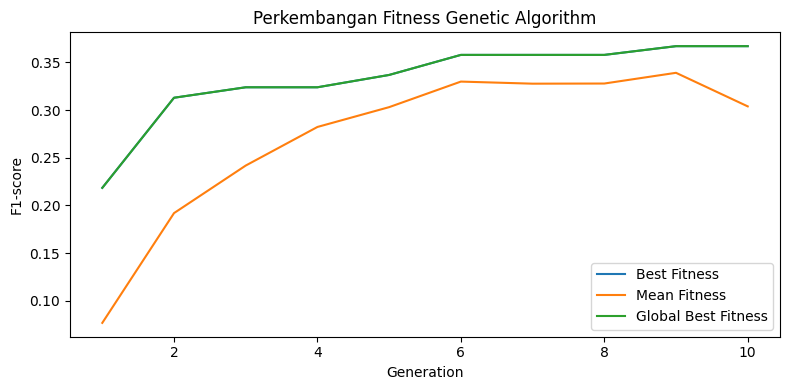

In [ ]:
# Menggunakan split train-validation yang sama dengan ANFIS tanpa GA
# Ini dilakukan agar jumlah data dan pembagian validation konsisten untuk perbandingan model
X_ga_train = X_train_inner
y_ga_train = y_train_inner
X_ga_val = X_val_inner
y_ga_val = y_val_inner

# Menampilkan distribusi target pada GA train sebelum SMOTE
print("Distribusi y_ga_train sebelum SMOTE:")
display(pd.Series(y_ga_train).value_counts().sort_index())

# Menampilkan distribusi target pada GA validation
# Validation GA tetap asli dan tidak terkena SMOTE
print("Distribusi y_ga_val asli:")
display(pd.Series(y_ga_val).value_counts().sort_index())

# Menerapkan SMOTE hanya pada GA train
# sampling_strategy sama dengan ANFIS tanpa GA agar perbandingan lebih adil
smote_ga = SMOTE(
    sampling_strategy=0.35,
    random_state=RANDOM_STATE,
    k_neighbors=5
)

X_ga_train_smote, y_ga_train_smote = smote_ga.fit_resample(
    X_ga_train,
    y_ga_train
)

# Menampilkan distribusi target pada GA train setelah SMOTE
print("Distribusi y_ga_train setelah SMOTE:")
display(pd.Series(y_ga_train_smote).value_counts().sort_index())

# Menentukan parameter Genetic Algorithm
ga_population_size = 12
ga_generations = 10
ga_inner_epochs = 120
ga_learning_rate = 0.08
ga_crossover_rate = 0.8
ga_mutation_rate = 0.10
ga_mutation_scale = 0.05
ga_elitism_count = 2

# Menjalankan optimasi Genetic Algorithm
# Train GA menggunakan data hasil SMOTE
# Validation GA tetap menggunakan data asli
optimized_centers, optimized_sigmas, optimized_threshold, best_ga_fitness, ga_history_df = run_genetic_algorithm(
    initial_centers,
    initial_sigmas,
    X_ga_train_smote,
    y_ga_train_smote,
    X_ga_val,
    y_ga_val,
    population_size=ga_population_size,
    generations=ga_generations,
    ga_inner_epochs=ga_inner_epochs,
    ga_learning_rate=ga_learning_rate,
    crossover_rate=ga_crossover_rate,
    mutation_rate=ga_mutation_rate,
    mutation_scale=ga_mutation_scale,
    elitism_count=ga_elitism_count
)

# Menampilkan history Genetic Algorithm
display(ga_history_df)

# Menampilkan hasil optimasi terbaik
print("Best GA Fitness:", best_ga_fitness)
print("Optimized Threshold:", optimized_threshold)

# Membuat visualisasi perkembangan fitness GA
plt.figure(figsize=(8, 4))
plt.plot(ga_history_df["Generation"], ga_history_df["Best Fitness"], label="Best Fitness")
plt.plot(ga_history_df["Generation"], ga_history_df["Mean Fitness"], label="Mean Fitness")
plt.plot(ga_history_df["Generation"], ga_history_df["Global Best Fitness"], label="Global Best Fitness")
plt.xlabel("Generation")
plt.ylabel("F1-score")
plt.title("Perkembangan Fitness Genetic Algorithm")
plt.legend()
plt.tight_layout()
plt.show()

## 23. Membership Function Setelah Optimasi GA

Bagian ini menampilkan parameter membership function setelah optimasi Genetic Algorithm. Visualisasi ini digunakan untuk melihat perubahan bentuk membership function sebelum dan sesudah optimasi.

,Feature,Membership,Center,Sigma
0,Air temperature [K],Low,0.261263,0.153388
1,Air temperature [K],Medium,0.565854,0.081443
2,Air temperature [K],High,0.591100,0.140854
3,Process temperature [K],Low,0.380453,0.105049
4,Process temperature [K],Medium,0.463658,0.147611
5,Process temperature [K],High,0.710018,0.200822
6,Rotational speed [rpm],Low,0.045656,0.089626
7,Rotational speed [rpm],Medium,0.369436,0.091553
8,Rotational speed [rpm],High,0.453626,0.030000
9,Torque [Nm],Low,0.539664,0.097688


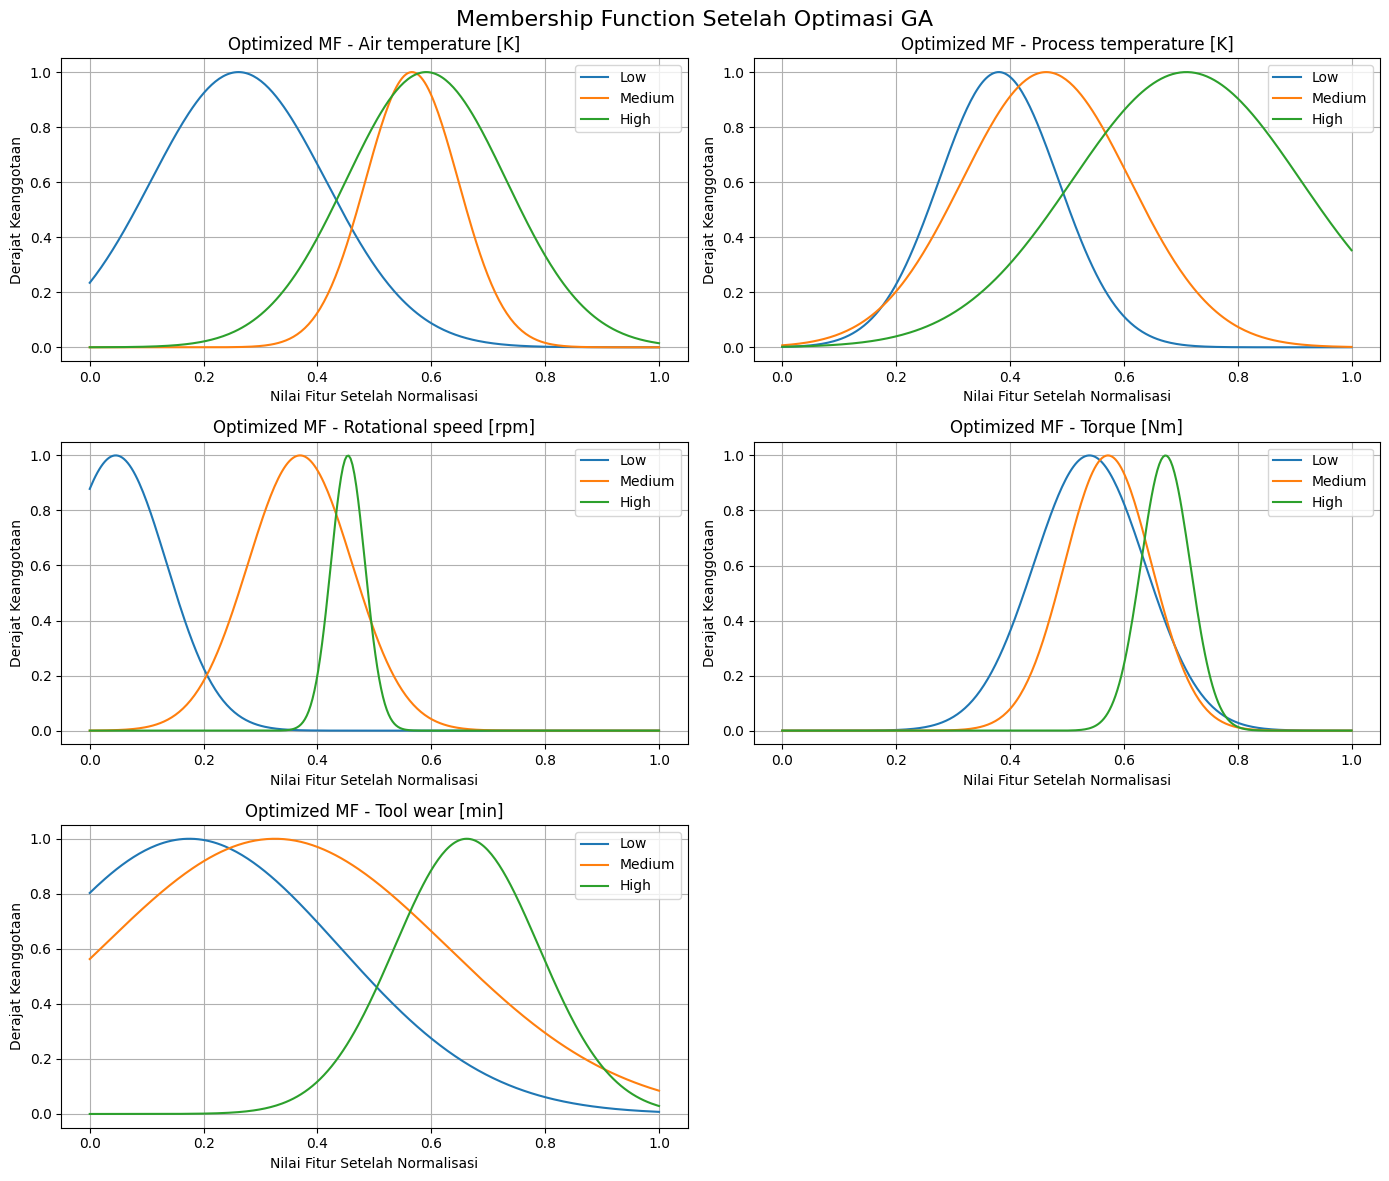

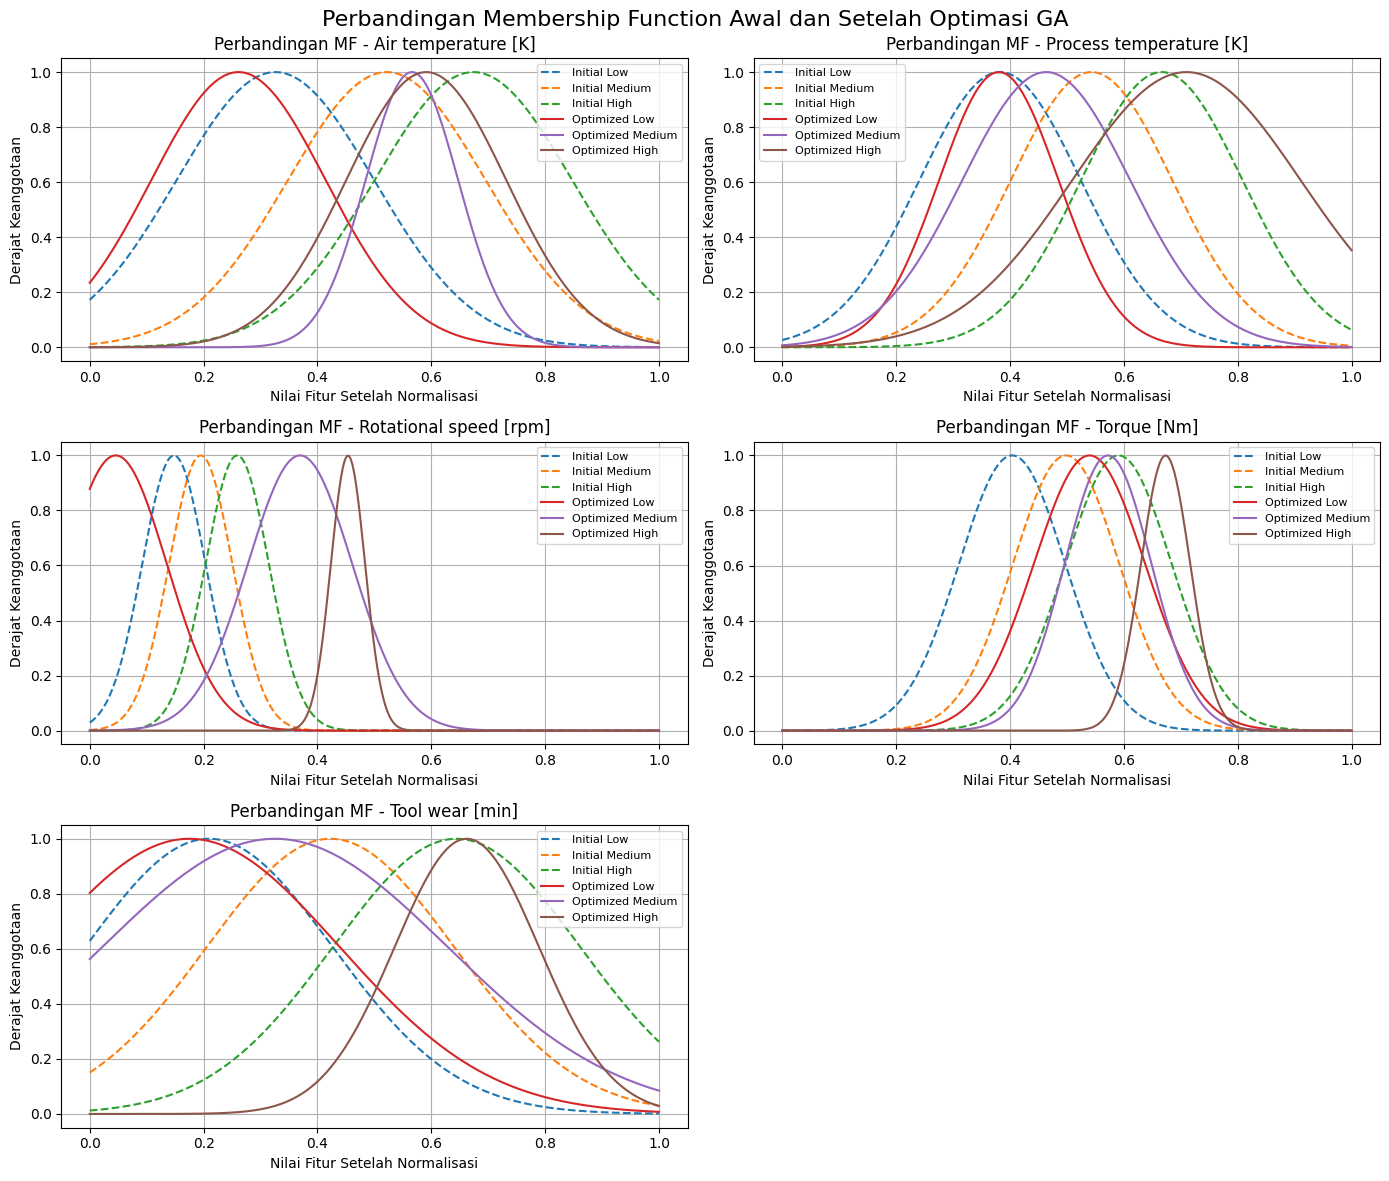

In [ ]:
# Membuat tabel parameter membership function hasil optimasi
optimized_mf_table = pd.DataFrame({
    "Feature": np.repeat(feature_columns, 3),
    "Membership": ["Low", "Medium", "High"] * len(feature_columns),
    "Center": optimized_centers.flatten(),
    "Sigma": optimized_sigmas.flatten()
})

# Menampilkan tabel parameter membership function hasil optimasi
display(optimized_mf_table)

# Visualisasi Membership Function Setelah Optimasi GA

n_cols = 2
n_rows = int(np.ceil(len(selected_membership_features) / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

x_values = np.linspace(0, 1, 300)

for i, feature_name in enumerate(selected_membership_features):
    feature_index = feature_columns.index(feature_name)

    axes[i].plot(
        x_values,
        gaussian_membership(
            x_values,
            optimized_centers[feature_index, 0],
            optimized_sigmas[feature_index, 0]
        ),
        label="Low"
    )

    axes[i].plot(
        x_values,
        gaussian_membership(
            x_values,
            optimized_centers[feature_index, 1],
            optimized_sigmas[feature_index, 1]
        ),
        label="Medium"
    )

    axes[i].plot(
        x_values,
        gaussian_membership(
            x_values,
            optimized_centers[feature_index, 2],
            optimized_sigmas[feature_index, 2]
        ),
        label="High"
    )

    axes[i].set_xlabel("Nilai Fitur Setelah Normalisasi")
    axes[i].set_ylabel("Derajat Keanggotaan")
    axes[i].set_title("Optimized MF - " + feature_name)
    axes[i].legend()
    axes[i].grid(True)

# Menghapus subplot kosong
for j in range(len(selected_membership_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Membership Function Setelah Optimasi GA", fontsize=16)
plt.tight_layout()
plt.show()


# Perbandingan Membership Function Awal dan Optimasi GA

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

for i, feature_name in enumerate(selected_membership_features):
    feature_index = feature_columns.index(feature_name)

    # Initial membership function
    axes[i].plot(
        x_values,
        gaussian_membership(
            x_values,
            initial_centers[feature_index, 0],
            initial_sigmas[feature_index, 0]
        ),
        linestyle="--",
        label="Initial Low"
    )

    axes[i].plot(
        x_values,
        gaussian_membership(
            x_values,
            initial_centers[feature_index, 1],
            initial_sigmas[feature_index, 1]
        ),
        linestyle="--",
        label="Initial Medium"
    )

    axes[i].plot(
        x_values,
        gaussian_membership(
            x_values,
            initial_centers[feature_index, 2],
            initial_sigmas[feature_index, 2]
        ),
        linestyle="--",
        label="Initial High"
    )

    # Optimized membership function
    axes[i].plot(
        x_values,
        gaussian_membership(
            x_values,
            optimized_centers[feature_index, 0],
            optimized_sigmas[feature_index, 0]
        ),
        label="Optimized Low"
    )

    axes[i].plot(
        x_values,
        gaussian_membership(
            x_values,
            optimized_centers[feature_index, 1],
            optimized_sigmas[feature_index, 1]
        ),
        label="Optimized Medium"
    )

    axes[i].plot(
        x_values,
        gaussian_membership(
            x_values,
            optimized_centers[feature_index, 2],
            optimized_sigmas[feature_index, 2]
        ),
        label="Optimized High"
    )

    axes[i].set_xlabel("Nilai Fitur Setelah Normalisasi")
    axes[i].set_ylabel("Derajat Keanggotaan")
    axes[i].set_title("Perbandingan MF - " + feature_name)
    axes[i].legend(fontsize=8)
    axes[i].grid(True)

# Menghapus subplot kosong
for j in range(len(selected_membership_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Perbandingan Membership Function Awal dan Setelah Optimasi GA", fontsize=16)
plt.tight_layout()
plt.show()

## 24. Training ANFIS dengan Parameter Hasil Optimasi GA

Setelah parameter membership function diperoleh dari GA, consequent layer dilatih ulang menggunakan parameter hasil optimasi. Model ini disebut ANFIS dengan GA karena menggunakan center, sigma, dan threshold hasil optimasi Genetic Algorithm.

Epoch: 100 Loss: 0.4625903860861318 F1: 0.629424778761062
Epoch: 200 Loss: 0.41490644559875667 F1: 0.6751930501930502
Epoch: 300 Loss: 0.3872720051050388 F1: 0.6913637416068534
Epoch: 400 Loss: 0.3695005662488321 F1: 0.6996128444545662
Epoch: 500 Loss: 0.35708431772759386 F1: 0.7043655281610496
Epoch: 600 Loss: 0.34782355809713644 F1: 0.7098515519568152
Epoch: 700 Loss: 0.3405570087553162 F1: 0.714605734767025
Epoch: 800 Loss: 0.33463010240663316 F1: 0.7222719141323792
Epoch: 900 Loss: 0.32965226760778216 F1: 0.7320435846119635
Epoch: 1000 Loss: 0.3253782186201423 F1: 0.7381745502998002


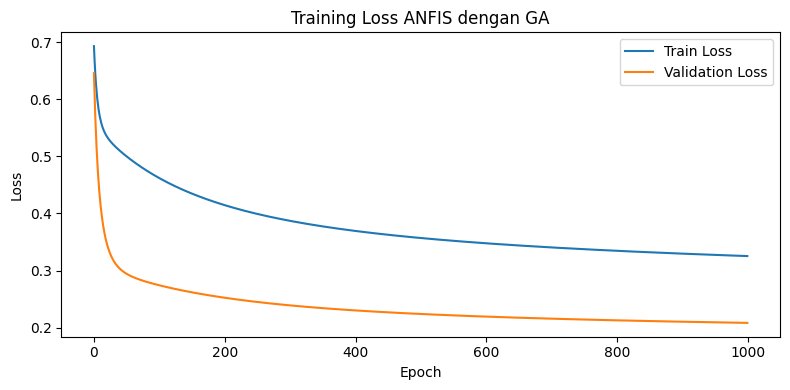

Best Threshold ANFIS dengan GA: 0.68
Best Validation F1 ANFIS dengan GA: 0.45714285714285713


In [ ]:
# Melakukan fuzzification pada train hasil SMOTE dan validation asli menggunakan parameter hasil optimasi GA
# Menggunakan X_train_inner_smote agar data training sama dengan ANFIS tanpa GA
# Menggunakan X_val_inner asli agar validation tetap realistis
fuzzy_train_inner_optimized = fuzzify_features(
    X_train_inner_smote,
    optimized_centers,
    optimized_sigmas
)

fuzzy_val_inner_optimized = fuzzify_features(
    X_val_inner,
    optimized_centers,
    optimized_sigmas
)

# Menentukan parameter training ANFIS dengan GA
epochs_with_ga = 1000
learning_rate_with_ga = 0.1
threshold_with_ga = optimized_threshold

# Melatih consequent layer ANFIS dengan parameter hasil optimasi GA
# Data train menggunakan hasil SMOTE
# Data validation tetap menggunakan data asli
weights_with_ga, bias_with_ga, history_with_ga = train_consequent_layer(
    fuzzy_train_inner_optimized,
    y_train_inner_smote,
    fuzzy_val=fuzzy_val_inner_optimized,
    y_val_input=y_val_inner,
    epochs=epochs_with_ga,
    learning_rate=learning_rate_with_ga,
    threshold=threshold_with_ga,
    verbose=True
)

# Menampilkan visualisasi training loss ANFIS dengan GA
plot_training_loss(
    history_with_ga,
    "Training Loss ANFIS dengan GA"
)

# Menghasilkan output validation untuk mencari threshold terbaik setelah training final
val_output_with_ga = predict_output(
    X_val_inner,
    optimized_centers,
    optimized_sigmas,
    weights_with_ga,
    bias_with_ga
)

# Mencari threshold terbaik berdasarkan F1-score pada validation asli
best_threshold_with_ga, best_val_f1_with_ga = find_best_threshold(
    y_val_inner,
    val_output_with_ga
)

# Menggunakan threshold terbaik dari validation asli untuk evaluasi akhir
threshold_with_ga = best_threshold_with_ga

print("Best Threshold ANFIS dengan GA:", threshold_with_ga)
print("Best Validation F1 ANFIS dengan GA:", best_val_f1_with_ga)

## 25. Evaluasi ANFIS dengan Genetic Algorithm

Evaluasi model ANFIS dengan GA dilakukan pada data test. Output model dikonversi menjadi kelas biner menggunakan threshold hasil optimasi GA.

Metrik Evaluasi ANFIS dengan GA:


,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.9625,0.444444,0.411765,0.427481,0.925694


Classification Report ANFIS dengan GA:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1932
           1       0.44      0.41      0.43        68

    accuracy                           0.96      2000
   macro avg       0.71      0.70      0.70      2000
weighted avg       0.96      0.96      0.96      2000



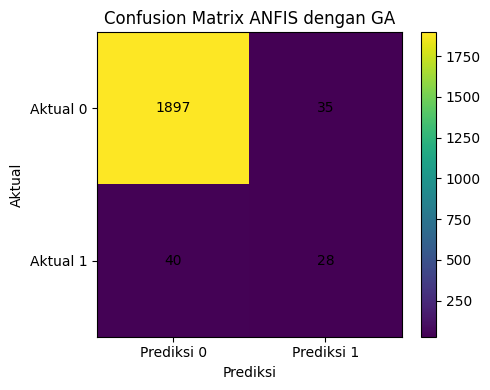

In [ ]:
# Menghasilkan output model pada data test menggunakan ANFIS dengan GA
output_with_ga = predict_output(
    X_test,
    optimized_centers,
    optimized_sigmas,
    weights_with_ga,
    bias_with_ga
)

# Mengevaluasi model ANFIS dengan GA
metrics_with_ga, y_pred_with_ga = evaluate_model(
    y_test,
    output_with_ga,
    threshold=threshold_with_ga
)

# Menampilkan metrik evaluasi ANFIS dengan GA
print("Metrik Evaluasi ANFIS dengan GA:")
display(pd.DataFrame([metrics_with_ga]))

# Menampilkan classification report
print("Classification Report ANFIS dengan GA:")
print(classification_report(y_test, y_pred_with_ga, zero_division=0))

# Menampilkan confusion matrix ANFIS dengan GA
plot_confusion_matrix_result(
    y_test,
    y_pred_with_ga,
    "Confusion Matrix ANFIS dengan GA"
)

## 26. Perbandingan ANFIS Tanpa GA dan ANFIS dengan GA

Bagian ini membandingkan performa ANFIS tanpa optimasi dan ANFIS dengan optimasi Genetic Algorithm. Perbandingan dilakukan menggunakan accuracy, precision, recall, F1-score, ROC-AUC, dan threshold.

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Threshold
0,ANFIS Tanpa GA,0.9445,0.287129,0.426471,0.343195,0.904861,0.54
1,ANFIS dengan GA,0.9625,0.444444,0.411765,0.427481,0.925694,0.68


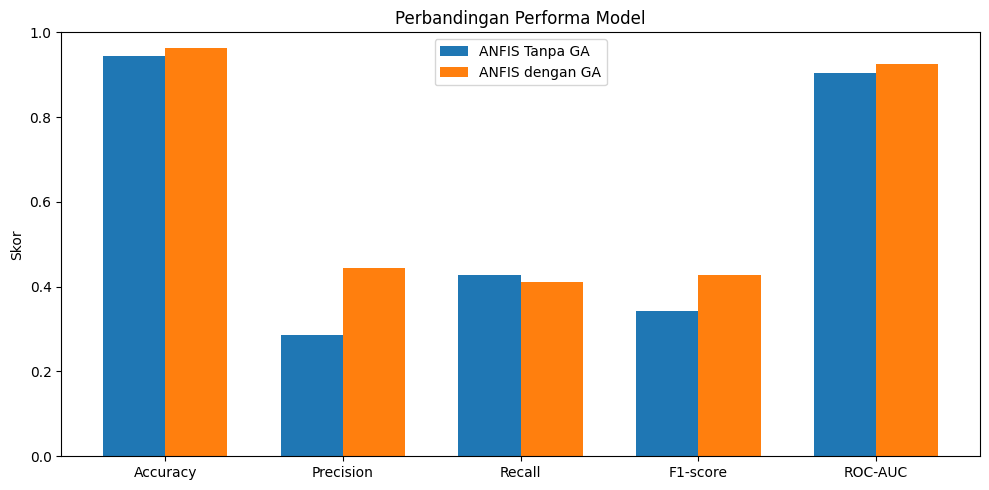

In [ ]:
# Membuat tabel perbandingan metrik evaluasi
comparison_df = pd.DataFrame([
    {
        "Model": "ANFIS Tanpa GA",
        "Accuracy": metrics_without_ga["Accuracy"],
        "Precision": metrics_without_ga["Precision"],
        "Recall": metrics_without_ga["Recall"],
        "F1-score": metrics_without_ga["F1-score"],
        "ROC-AUC": metrics_without_ga["ROC-AUC"],
        "Threshold": threshold_without_ga
    },
    {
        "Model": "ANFIS dengan GA",
        "Accuracy": metrics_with_ga["Accuracy"],
        "Precision": metrics_with_ga["Precision"],
        "Recall": metrics_with_ga["Recall"],
        "F1-score": metrics_with_ga["F1-score"],
        "ROC-AUC": metrics_with_ga["ROC-AUC"],
        "Threshold": threshold_with_ga
    }
])

# Menampilkan tabel perbandingan
display(comparison_df)

# Menentukan metrik yang divisualisasikan
metric_names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

# Membuat visualisasi perbandingan metrik
plot_metric_comparison(comparison_df, metric_names)

## 27. Analisis False Negative

False negative adalah kondisi ketika data aktual failure diprediksi sebagai normal. Pada kasus prediksi kegagalan mesin, false negative penting diperhatikan karena model gagal mendeteksi kondisi yang seharusnya diklasifikasikan sebagai failure.

,Model,False Negative
0,ANFIS Tanpa GA,39
1,ANFIS dengan GA,40


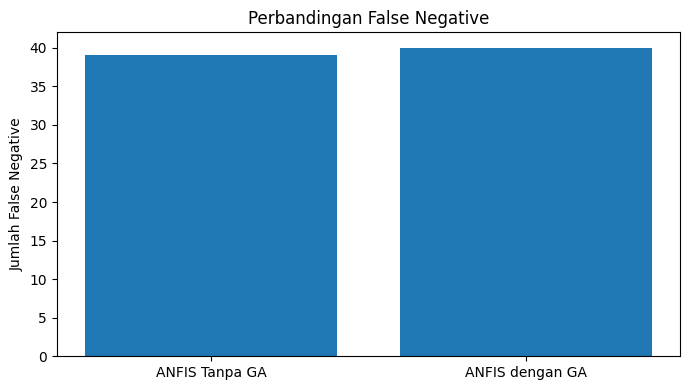

In [ ]:
# Menghitung confusion matrix untuk kedua model
cm_without_ga = confusion_matrix(y_test, y_pred_without_ga)
cm_with_ga = confusion_matrix(y_test, y_pred_with_ga)

# Mengambil nilai false negative dari confusion matrix
false_negative_without_ga = cm_without_ga[1, 0]
false_negative_with_ga = cm_with_ga[1, 0]

# Membuat tabel analisis false negative
false_negative_df = pd.DataFrame({
    "Model": ["ANFIS Tanpa GA", "ANFIS dengan GA"],
    "False Negative": [false_negative_without_ga, false_negative_with_ga]
})

# Menampilkan tabel false negative
display(false_negative_df)

# Membuat visualisasi perbandingan false negative
plt.figure(figsize=(7, 4))
plt.bar(false_negative_df["Model"], false_negative_df["False Negative"])
plt.ylabel("Jumlah False Negative")
plt.title("Perbandingan False Negative")
plt.tight_layout()
plt.show()

## 28. Contoh Prediksi Data Uji

Bagian ini menampilkan contoh prediksi dari satu data uji. Output yang ditampilkan adalah nilai aktual, output model, dan hasil prediksi kelas dari ANFIS tanpa GA dan ANFIS dengan GA.

In [ ]:
# Memilih satu data uji
sample_index = 0
single_sample_scaled = X_test[sample_index].reshape(1, -1)
single_sample_actual = y_test[sample_index]

# Menghasilkan prediksi ANFIS tanpa GA
single_output_without_ga = predict_output(
    single_sample_scaled,
    initial_centers,
    initial_sigmas,
    weights_without_ga,
    bias_without_ga
)

single_pred_without_ga = output_to_class(single_output_without_ga, threshold_without_ga)

# Menghasilkan prediksi ANFIS dengan GA
single_output_with_ga = predict_output(
    single_sample_scaled,
    optimized_centers,
    optimized_sigmas,
    weights_with_ga,
    bias_with_ga
)

single_pred_with_ga = output_to_class(single_output_with_ga, threshold_with_ga)

# Membuat tabel hasil prediksi satu data uji
single_prediction_result = pd.DataFrame({
    "Model": ["ANFIS Tanpa GA", "ANFIS dengan GA"],
    "Actual Machine Failure": [single_sample_actual, single_sample_actual],
    "Model Output": [single_output_without_ga[0], single_output_with_ga[0]],
    "Prediction": [single_pred_without_ga[0], single_pred_with_ga[0]],
    "Threshold": [threshold_without_ga, threshold_with_ga]
})

# Menampilkan hasil prediksi satu data uji
display(single_prediction_result)

,Model,Actual Machine Failure,Model Output,Prediction,Threshold
0,ANFIS Tanpa GA,0,0.599817,1,0.54
1,ANFIS dengan GA,0,0.595469,0,0.68


## 29. Menyimpan Parameter Model

Bagian ini menyimpan scaler, daftar fitur, parameter ANFIS tanpa GA, dan parameter ANFIS dengan GA. File hasil penyimpanan dapat digunakan kembali untuk pengujian atau pengembangan sistem berikutnya.

In [ ]:
# Membuat dictionary parameter ANFIS tanpa GA
anfis_without_ga_params = {
    "centers": initial_centers,
    "sigmas": initial_sigmas,
    "weights": weights_without_ga,
    "bias": bias_without_ga,
    "threshold": threshold_without_ga,
    "feature_columns": feature_columns,
    "metrics": metrics_without_ga
}

# Membuat dictionary parameter ANFIS dengan GA
anfis_with_ga_params = {
    "centers": optimized_centers,
    "sigmas": optimized_sigmas,
    "weights": weights_with_ga,
    "bias": bias_with_ga,
    "threshold": threshold_with_ga,
    "feature_columns": feature_columns,
    "metrics": metrics_with_ga,
    "ga_history": ga_history_df
}

# Menyimpan scaler
joblib.dump(scaler, "scaler.pkl")

# Menyimpan daftar fitur
joblib.dump(feature_columns, "feature_columns.pkl")

# Menyimpan parameter ANFIS tanpa GA
joblib.dump(anfis_without_ga_params, "anfis_without_ga_params.pkl")

# Menyimpan parameter ANFIS dengan GA
joblib.dump(anfis_with_ga_params, "anfis_with_ga_params.pkl")

# Menampilkan daftar file yang berhasil disimpan
saved_files = [
    "scaler.pkl",
    "feature_columns.pkl",
    "anfis_without_ga_params.pkl",
    "anfis_with_ga_params.pkl"
]

print("File yang berhasil disimpan:")
for file_name in saved_files:
    print(file_name)

File yang berhasil disimpan:
scaler.pkl
feature_columns.pkl
anfis_without_ga_params.pkl
anfis_with_ga_params.pkl
